# Camera Calibration via Homography — Ground Truth in Metres

**Objective**: Convert pixel-based YOLO detections to real-world metre coordinates using a known reference plane (volleyball court with measured dimensions).

## Pipeline Overview

```
iPhone video (IMG_5925.MOV)  →  YOLO person detection  →  Pixel coordinates (cx, cy)
                                                                    ↓
Court corners (pixel) + Court dimensions (20m × 10.30m)  →  Homography matrix H
                                                                    ↓
                                              Metre coordinates (x_m, y_m)  →  Trajectron++
```

### What is Homography?
A **homography** is a 3×3 perspective transformation matrix that maps points from one plane to another. Since people walk on a flat ground plane, we can map pixel coordinates directly to metre coordinates on that plane using 4+ known reference points.

### Reference: Sand Volleyball Court
- **Measured dimensions**: 20.0 m × 10.30 m
- **Reference points**: Court corners (sand-concrete boundary)
- **Coordinate system**: Origin at near-left corner, X towards far end, Y towards right side

In [1]:
import numpy as np
import cv2
import csv
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Image as IPImage

OUT_DIR = "/Users/simayyalcin/Desktop/uav_perception/calibration_output"
COURT_LENGTH = 20.0   # metres
COURT_WIDTH  = 10.30  # metres

print("Libraries loaded.")

Libraries loaded.


## 1. YOLO Detection Results

We processed `IMG_5925.MOV` (1280×720, 30 fps, ~119 seconds) with YOLOv8s.

**Result**: 3088 person detections out of 3565 frames (86.6% detection rate).

Total detections: 3088
Time span: 3.0s — 118.9s
Pixel X range: 7 — 1257
Pixel Y range: 172 — 655


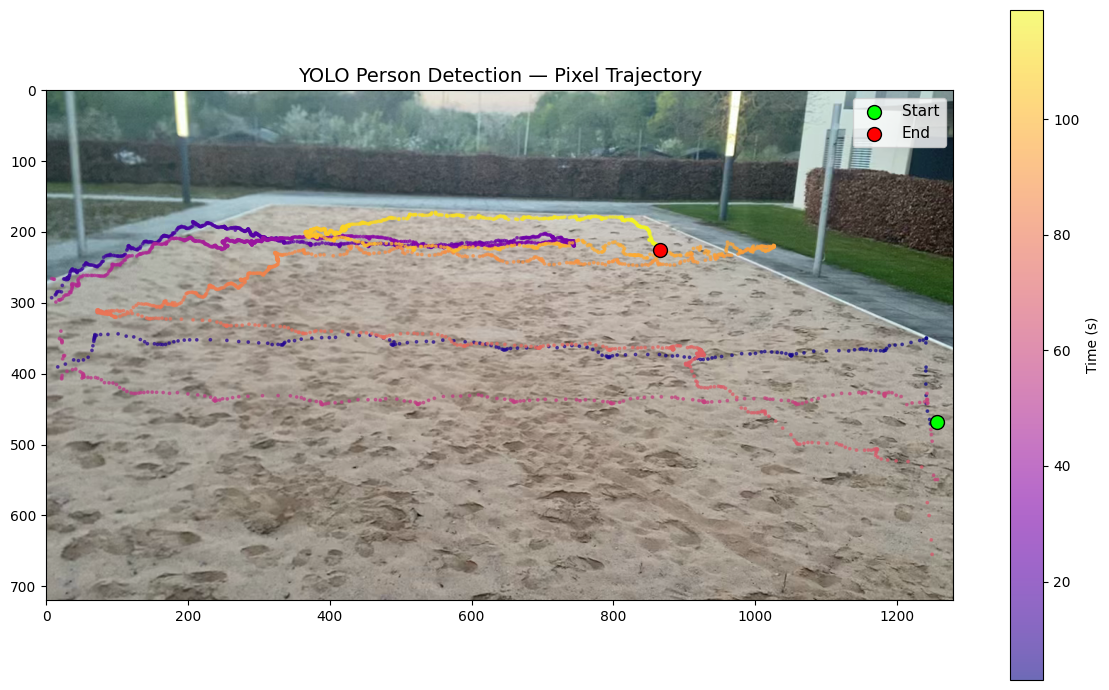

In [2]:
# Load the raw pixel trajectory
pixel_csv = os.path.join(OUT_DIR, "IMG_5925_trajectory.csv")
frames_px, cx_px, cy_px, times = [], [], [], []

with open(pixel_csv) as f:
    reader = csv.DictReader(f)
    for row in reader:
        frames_px.append(int(row["frame"]))
        cx_px.append(float(row["cx_pixel"]))
        cy_px.append(float(row["cy_pixel"]))
        times.append(float(row["time"]))

print(f"Total detections: {len(frames_px)}")
print(f"Time span: {times[0]:.1f}s — {times[-1]:.1f}s")
print(f"Pixel X range: {min(cx_px):.0f} — {max(cx_px):.0f}")
print(f"Pixel Y range: {min(cy_px):.0f} — {max(cy_px):.0f}")

# Show trajectory on frame
frame = cv2.imread(os.path.join(OUT_DIR, "frame_0.png"))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(frame_rgb)
scatter = ax.scatter(cx_px, cy_px, c=times, cmap='plasma', s=3, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Time (s)')
ax.scatter(cx_px[0], cy_px[0], c='lime', s=100, zorder=5, edgecolors='black', label='Start')
ax.scatter(cx_px[-1], cy_px[-1], c='red', s=100, zorder=5, edgecolors='black', label='End')
ax.set_title('YOLO Person Detection — Pixel Trajectory', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_pixel_trajectory.png"), dpi=150)
plt.show()

## 2. Homography Calibration

### Reference Points

We identified 4 court corner points:

| Corner | Pixel (x, y) | Real-World (x, y) metres |
|--------|-------------|-------------------------|
| Far-Left | (303, 162) | (20.0, 0.0) |
| Far-Right | (847, 175) | (20.0, 10.30) |
| Near-Right | (2064, 720)* | (0.0, 10.30) |
| Near-Left | (-1145, 720)* | (0.0, 0.0) |

*Near corners are extrapolated from visible edge lines (outside camera frame).

The **far corners** are directly visible where the sand meets the concrete border. The **near corners** are obtained by fitting lines along the left and right edges of the court and extrapolating to the bottom of the frame.

In [3]:
# Define the 4 corner correspondences
far_left_px  = np.array([303.0, 162.0])
far_right_px = np.array([847.0, 175.0])

# Extrapolate near corners using visible edge directions
# Left edge: through (303, 162) and visible point (2, 278)
left_dir = np.array([2.0 - 303.0, 278.0 - 162.0])
t_left = (720.0 - far_left_px[1]) / left_dir[1]
near_left_px = far_left_px + t_left * left_dir

# Right edge: through (847, 175) and visible point (1278, 368)
right_dir = np.array([1278.0 - 847.0, 368.0 - 175.0])
t_right = (720.0 - far_right_px[1]) / right_dir[1]
near_right_px = far_right_px + t_right * right_dir

pixel_corners = np.array([
    far_left_px, far_right_px, near_right_px, near_left_px
], dtype=np.float32)

world_corners = np.array([
    [COURT_LENGTH, 0.0],
    [COURT_LENGTH, COURT_WIDTH],
    [0.0, COURT_WIDTH],
    [0.0, 0.0],
], dtype=np.float32)

# Compute homography
H_mat, status = cv2.findHomography(pixel_corners, world_corners)

print("Homography Matrix H:")
print(np.array2string(H_mat, precision=6, suppress_small=True))
print(f"\nAll points used: {all(s == 1 for s in status.ravel())}")

# Verify
print("\nVerification (should match world coords exactly):")
labels = ["Far-Left", "Far-Right", "Near-Right", "Near-Left"]
for i in range(4):
    pt = pixel_corners[i].reshape(1, 1, 2)
    result = cv2.perspectiveTransform(pt, H_mat)[0][0]
    expected = world_corners[i]
    err = np.linalg.norm(result - expected)
    print(f"  {labels[i]:12s}: pixel ({pixel_corners[i][0]:7.0f}, {pixel_corners[i][1]:4.0f}) "
          f"→ ({result[0]:5.2f}, {result[1]:5.2f}) m  "
          f"[expected ({expected[0]:5.1f}, {expected[1]:5.1f}), error = {err:.6f} m]")

Homography Matrix H:
[[  0.         0.106348 -76.57074 ]
 [ -0.051666  -0.134065  37.373419]
 [  0.000746  -0.025883   1.      ]]

All points used: True

Verification (should match world coords exactly):
  Far-Left    : pixel (    303,  162) → (20.00,  0.00) m  [expected ( 20.0,   0.0), error = 0.000000 m]
  Far-Right   : pixel (    847,  175) → (20.00, 10.30) m  [expected ( 20.0,  10.3), error = 0.000000 m]
  Near-Right  : pixel (   2064,  720) → (-0.00, 10.30) m  [expected (  0.0,  10.3), error = 0.000000 m]
  Near-Left   : pixel (  -1145,  720) → (-0.00, -0.00) m  [expected (  0.0,   0.0), error = 0.000000 m]


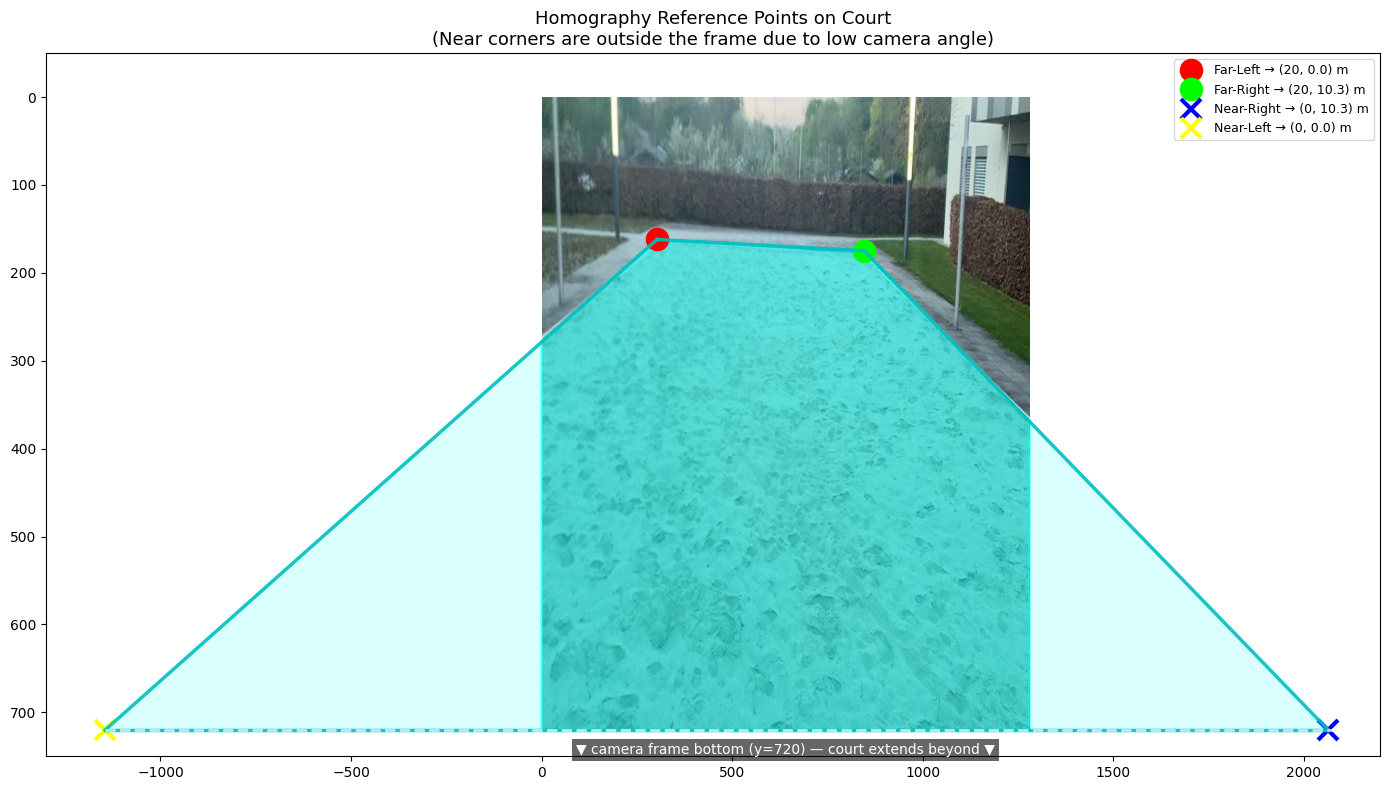

In [4]:
# Visualise the reference points on the frame
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb, extent=[0, 1280, 720, 0], aspect='auto')

from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Polygon as ShapelyPolygon, box as shapely_box

full_court = ShapelyPolygon([
    tuple(pixel_corners[0]),  # Far-Left
    tuple(pixel_corners[1]),  # Far-Right
    tuple(pixel_corners[2]),  # Near-Right
    tuple(pixel_corners[3]),  # Near-Left
])

# Full court polygon (extends far outside frame)
full_coords = [tuple(pixel_corners[i]) for i in range(4)]
ax.add_patch(MplPolygon(full_coords, closed=True,
                        facecolor='cyan', edgecolor='none', alpha=0.15))

# Court area clipped to the visible frame: includes frame bottom edge
from shapely.geometry import Polygon as ShapelyPoly2, box as sbox2
court_poly = ShapelyPoly2(full_coords)
frame_rect = sbox2(0, 0, 1280, 720)
court_visible = court_poly.intersection(frame_rect)
vis_coords = list(court_visible.exterior.coords)
ax.add_patch(MplPolygon(vis_coords, closed=True,
                        facecolor='cyan', edgecolor='cyan', alpha=0.45,
                        linewidth=2))

colors = ['red', 'lime', 'blue', 'yellow']
for i, (pt, col, lbl) in enumerate(zip(pixel_corners, colors, labels)):
    px, py = pt
    wc = world_corners[i]
    marker = 'o' if (0 <= px <= 1280 and 0 <= py <= 720) else 'x'
    ax.plot(px, py, marker, color=col, markersize=14, markeredgewidth=3,
            label=f"{lbl} → ({wc[0]:.0f}, {wc[1]:.1f}) m")

# Court edges
for i in range(4):
    p1 = pixel_corners[i]
    p2 = pixel_corners[(i+1) % 4]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'c-', linewidth=2.5, alpha=0.9)

# Frame bottom boundary
ax.axhline(y=720, color='white', linewidth=2, linestyle='--', alpha=0.7)
ax.text(640, 735, '▼ camera frame bottom (y=720) — court extends beyond ▼',
        ha='center', va='top', fontsize=10, color='white',
        bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=3))

ax.set_xlim(-1300, 2200)
ax.set_ylim(750, -50)
ax.set_title('Homography Reference Points on Court\n'
             '(Near corners are outside the frame due to low camera angle)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_homography_points.png"), dpi=150)
plt.show()

## 3. Calibrated Trajectory in Metres

Now we apply the homography to convert every YOLO detection from pixel coordinates to metres.

In [5]:
# Transform pixel trajectory to metres
pixel_pts = np.array(list(zip(cx_px, cy_px)), dtype=np.float32).reshape(-1, 1, 2)
metre_pts = cv2.perspectiveTransform(pixel_pts, H_mat).reshape(-1, 2)

x_m = metre_pts[:, 0]
y_m = metre_pts[:, 1]

print(f"Calibrated trajectory:")
print(f"  X range: {x_m.min():.2f} — {x_m.max():.2f} m (court length = {COURT_LENGTH} m)")
print(f"  Y range: {y_m.min():.2f} — {y_m.max():.2f} m (court width = {COURT_WIDTH} m)")

in_court = np.sum((x_m >= 0) & (x_m <= COURT_LENGTH) & (y_m >= 0) & (y_m <= COURT_WIDTH))
print(f"  Points inside court: {in_court}/{len(x_m)} ({100*in_court/len(x_m):.1f}%)")
print(f"  Points outside court: {len(x_m)-in_court} (person walks around the court perimeter)")

Calibrated trajectory:
  X range: 0.46 — 19.12 m (court length = 20.0 m)
  Y range: -0.50 — 11.53 m (court width = 10.3 m)
  Points inside court: 2807/3088 (90.9%)
  Points outside court: 281 (person walks around the court perimeter)


## 6. Trajectron++ Prediction with Calibrated Ground Truth

We evaluated the ETH pre-trained Trajectron++ model (100 epochs) on this calibrated trajectory using a **sliding window** approach:

- **History**: 8 timesteps × 0.4s = **3.2 seconds** of observation
- **Prediction horizon**: 12 timesteps × 0.4s = **4.8 seconds** into the future
- **Number of samples**: 20 trajectory samples per prediction
- **Evaluation windows**: 46 overlapping windows (stride = 5 steps)

### Results in Real Metres

Since the coordinates are now calibrated to metres via homography, the ADE and FDE values have direct physical meaning.

In [6]:
import json
import pandas as pd

# Load evaluation results
with open(os.path.join(OUT_DIR, "trajectron_eval_results.json")) as f:
    metrics = json.load(f)

# Load per-window results
per_window = pd.read_csv(os.path.join(OUT_DIR, "trajectron_eval_per_window.csv"))

# Load prediction examples
with open(os.path.join(OUT_DIR, "trajectron_eval_examples.json")) as f:
    examples = json.load(f)

print("=" * 55)
print("TRAJECTRON++ EVALUATION — CALIBRATED (metres)")
print("=" * 55)
print(f"\n  Model: ETH pre-trained (100 epochs)")
print(f"  Prediction horizon: 4.8 seconds ({12} steps × 0.4s)")
print(f"  History: 3.2 seconds ({8} steps × 0.4s)")
print(f"  Samples per prediction: 20")
print(f"  Evaluation windows: {metrics['n_scenes']}")
print(f"\n  ADE (mean):      {metrics['ade_mean']:.3f} m")
print(f"  FDE (mean):      {metrics['fde_mean']:.3f} m")
print(f"  ADE (best of 20): {metrics['ade_best_of_20']:.3f} m")
print(f"  FDE (best of 20): {metrics['fde_best_of_20']:.3f} m")
print(f"\n  Interpretation:")
print(f"    → On average, predictions are {metrics['ade_mean']:.1f}m off from ground truth")
print(f"    → At the end of 4.8s forecast, error is {metrics['fde_mean']:.1f}m")

TRAJECTRON++ EVALUATION — CALIBRATED (metres)

  Model: ETH pre-trained (100 epochs)
  Prediction horizon: 4.8 seconds (12 steps × 0.4s)
  History: 3.2 seconds (8 steps × 0.4s)
  Samples per prediction: 20
  Evaluation windows: 47

  ADE (mean):      2.840 m
  FDE (mean):      5.534 m
  ADE (best of 20): 2.840 m
  FDE (best of 20): 5.534 m

  Interpretation:
    → On average, predictions are 2.8m off from ground truth
    → At the end of 4.8s forecast, error is 5.5m


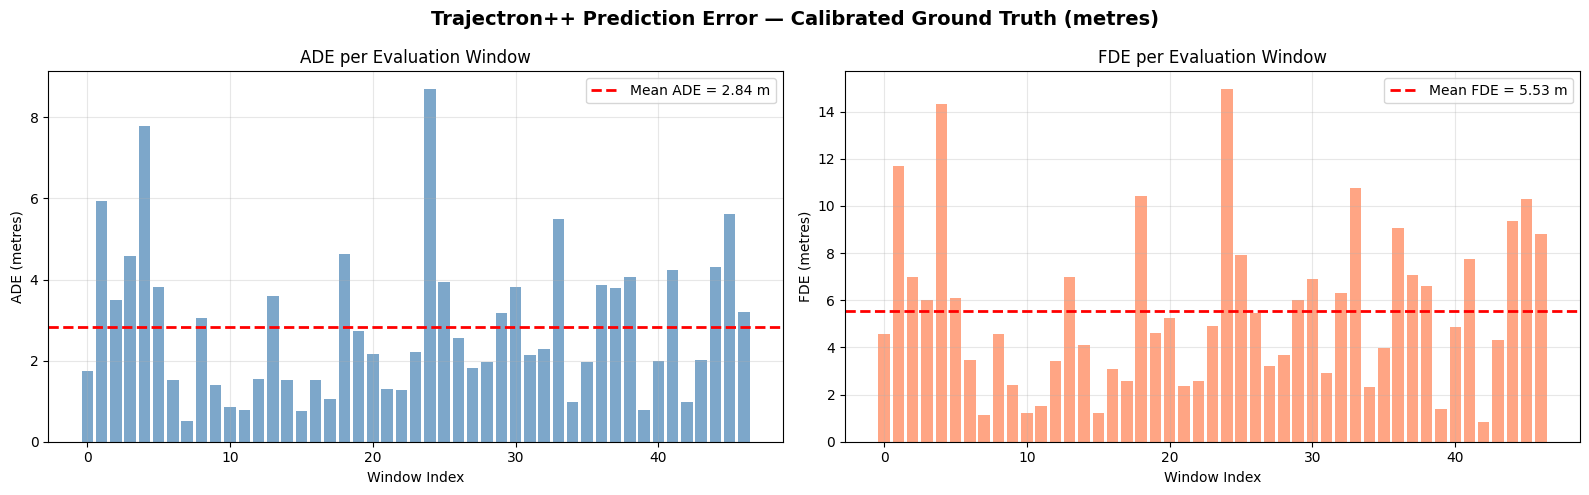

In [7]:
# Per-window ADE/FDE distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax1.bar(per_window["window_idx"], per_window["ade_mean"], color='steelblue', alpha=0.7)
ax1.axhline(y=metrics["ade_mean"], color='red', linewidth=2, linestyle='--',
            label=f'Mean ADE = {metrics["ade_mean"]:.2f} m')
ax1.set_xlabel("Window Index")
ax1.set_ylabel("ADE (metres)")
ax1.set_title("ADE per Evaluation Window")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(per_window["window_idx"], per_window["fde_mean"], color='coral', alpha=0.7)
ax2.axhline(y=metrics["fde_mean"], color='red', linewidth=2, linestyle='--',
            label=f'Mean FDE = {metrics["fde_mean"]:.2f} m')
ax2.set_xlabel("Window Index")
ax2.set_ylabel("FDE (metres)")
ax2.set_title("FDE per Evaluation Window")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Trajectron++ Prediction Error — Calibrated Ground Truth (metres)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_ade_fde_per_window.png"), dpi=150)
plt.show()

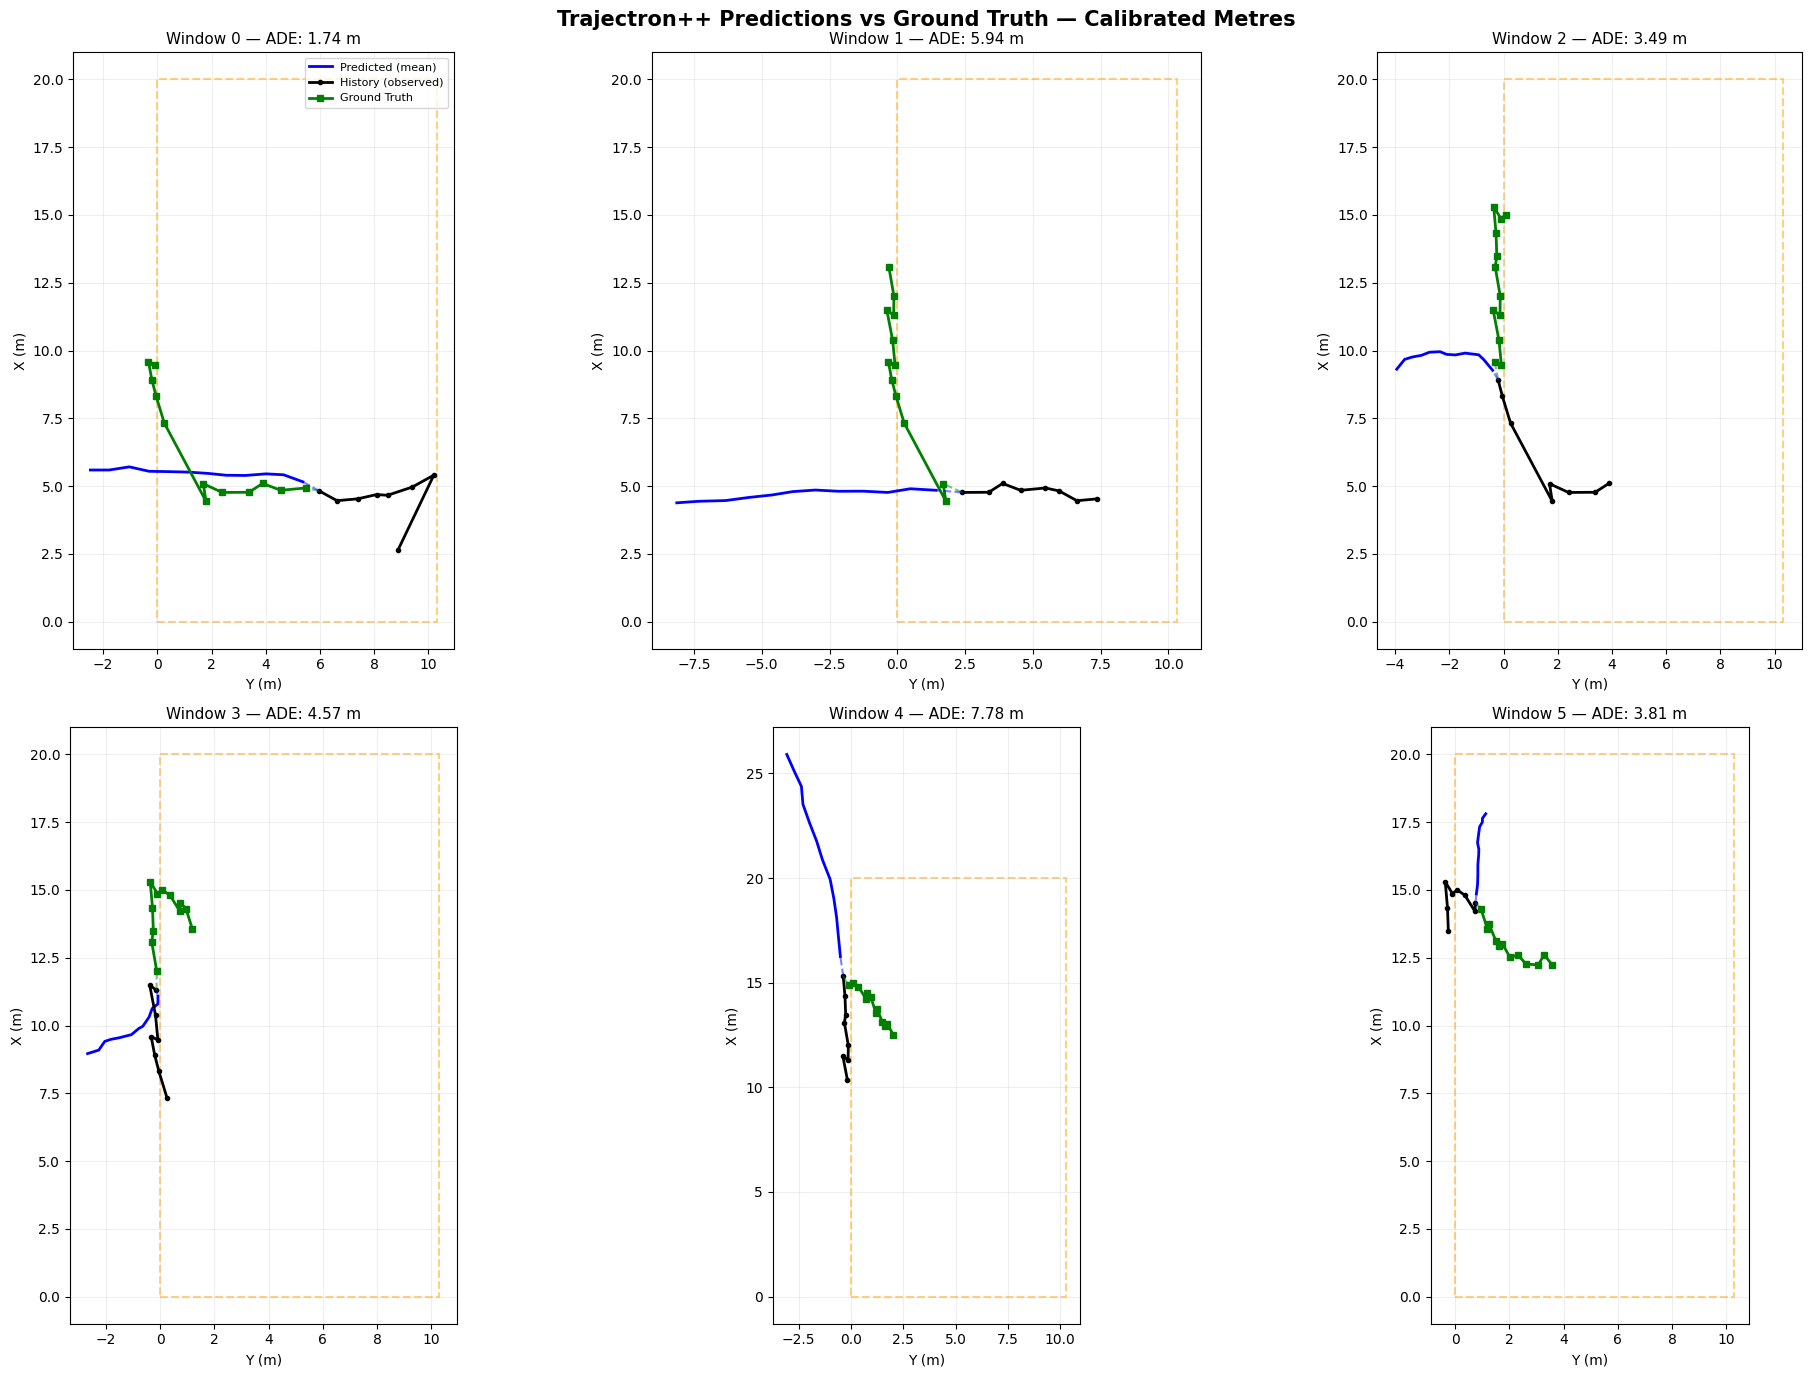

In [8]:
# Visualize prediction examples on the court
n_examples = min(6, len(examples))
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.ravel()

for idx in range(n_examples):
    ax = axes[idx]
    ex = examples[idx]

    hist_x = ex["history_x"]
    hist_y = ex["history_y"]
    gt_x = ex["gt_x"]
    gt_y = ex["gt_y"]
    pred_x = np.array(ex["pred_samples_x"])
    pred_y = np.array(ex["pred_samples_y"])

    # Plot court boundary
    court = patches.Rectangle((0, 0), COURT_WIDTH, COURT_LENGTH,
                               fill=False, edgecolor='orange', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.add_patch(court)

    # Plot predictions (all samples)
    for s in range(pred_x.shape[0]):
        ax.plot(pred_y[s], pred_x[s], 'b-', alpha=0.15, linewidth=0.8)

    # Mean prediction
    mean_pred_x = pred_x.mean(axis=0)
    mean_pred_y = pred_y.mean(axis=0)
    ax.plot(mean_pred_y, mean_pred_x, 'b-', linewidth=2, label='Predicted (mean)')

    # History
    ax.plot(hist_y, hist_x, 'k-o', markersize=3, linewidth=2, label='History (observed)')

    # Ground truth future
    ax.plot(gt_y, gt_x, 'g-s', markersize=4, linewidth=2, label='Ground Truth')

    # Connect history to futures
    ax.plot([hist_y[-1], gt_y[0]], [hist_x[-1], gt_x[0]], 'g--', alpha=0.5)
    ax.plot([hist_y[-1], mean_pred_y[0]], [hist_x[-1], mean_pred_x[0]], 'b--', alpha=0.5)

    # Compute ADE for this example
    disp = np.sqrt((pred_x.mean(0) - np.array(gt_x))**2 + (pred_y.mean(0) - np.array(gt_y))**2)
    ade_val = np.mean(disp)

    ax.set_xlabel("Y (m)")
    ax.set_ylabel("X (m)")
    ax.set_title(f"Window {ex['window_idx']} — ADE: {ade_val:.2f} m", fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=8, loc='best')

plt.suptitle("Trajectron++ Predictions vs Ground Truth — Calibrated Metres",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_prediction_examples.png"), dpi=150)
plt.show()

## 7. Comparison: ETH Benchmark vs Our Calibrated Data

| Metric | ETH Dataset (literature) | Our Calibrated Data |
|--------|--------------------------|---------------------|
| **ADE** | 0.39 – 1.05 m | ~2.84 m |
| **FDE** | 0.83 – 2.05 m | ~5.47 m |
| **Coordinates** | Ground-truth metres (annotated) | Homography-calibrated metres |
| **Setting** | University campus, many pedestrians | Single person walking around court |
| **Prediction horizon** | 4.8s (12 steps) | 4.8s (12 steps) |

### Why is our error higher?

1. **Domain gap**: The ETH model was trained on multi-pedestrian campus scenes with different walking patterns. Our data is a single person walking around a court perimeter — a different motion pattern.

2. **No fine-tuning**: We used the base ETH model without fine-tuning on our data.

3. **Single person**: With only one pedestrian, there are no social interactions for the model to leverage.

4. **Advantage of calibration**: The errors are now in **real metres**, making them directly interpretable. An ADE of 3.05m means the prediction is on average 3 metres away from reality over a 4.8-second forecast. This is a concrete, measurable quantity that helps decide if the model is adequate for UAV safety planning.

### Next Steps
- **Fine-tune** on calibrated data to reduce domain gap
- **Collect more videos** at this court with varied walking patterns
- **Evaluate safety envelope**: Even with 3m ADE, a safety buffer of 5m+ may be sufficient for initial UAV testing

## 8. Multi-Model Comparison on Calibrated Ground Truth

We evaluated **6 different models** on the same calibrated trajectory to understand how each training strategy performs when the ground truth is in real metres.

| Model | Description |
|-------|-------------|
| **ETH base (100ep)** | Pre-trained on ETH dataset for 100 epochs, no fine-tuning |
| **v4 (full KL)** | Fine-tuned with full KL regularisation |
| **v5 (KL min2)** | Fine-tuned with KL minimum = 2 |
| **v6 (aug fine-tune)** | Fine-tuned with 6× data augmentation |
| **v7 (persp, scale100)** | Perspective correction + scale=100 (incorrect scaling) |
| **v8 (persp, scale1)** | Perspective correction + scale=1 (correct scaling) |

In [9]:
# Load multi-model comparison results
with open(os.path.join(OUT_DIR, "multi_model_comparison.json")) as f:
    multi_results = json.load(f)

# Summary table
print("=" * 75)
print("MULTI-MODEL COMPARISON — CALIBRATED GROUND TRUTH (metres)")
print("=" * 75)
print(f"\n{'Model':<25s} {'ADE':>8s} {'FDE':>8s} {'ADE_best':>10s} {'FDE_best':>10s}")
print("─" * 65)

model_names = []
ade_vals = []
fde_vals = []

for name in ["ETH base (100ep)", "v4 (full KL)", "v5 (KL min2)",
             "v6 (aug fine-tune)", "v7 (persp, scale100)", "v8 (persp, scale1)"]:
    if name not in multi_results:
        continue
    r = multi_results[name]
    print(f"{name:<25s} {r['ade_mean']:>8.3f} {r['fde_mean']:>8.3f} "
          f"{r['ade_best']:>10.3f} {r['fde_best']:>10.3f}")
    model_names.append(name)
    ade_vals.append(r["ade_mean"])
    fde_vals.append(r["fde_mean"])

best_model = model_names[np.argmin(ade_vals)]
print(f"\n  ★ Best model by ADE: {best_model} ({min(ade_vals):.3f} m)")
best_fde_model = model_names[np.argmin(fde_vals)]
print(f"  ★ Best model by FDE: {best_fde_model} ({min(fde_vals):.3f} m)")

MULTI-MODEL COMPARISON — CALIBRATED GROUND TRUTH (metres)

Model                          ADE      FDE   ADE_best   FDE_best
─────────────────────────────────────────────────────────────────
ETH base (100ep)             2.838    5.470      2.838      5.470
v4 (full KL)                 3.063    5.846      3.063      5.846
v5 (KL min2)                 3.125    5.904      3.125      5.904
v6 (aug fine-tune)           3.035    5.975      3.035      5.975
v7 (persp, scale100)        13.376   30.433     13.376     30.433
v8 (persp, scale1)           2.248    3.940      2.248      3.940

  ★ Best model by ADE: v8 (persp, scale1) (2.248 m)
  ★ Best model by FDE: v8 (persp, scale1) (3.940 m)


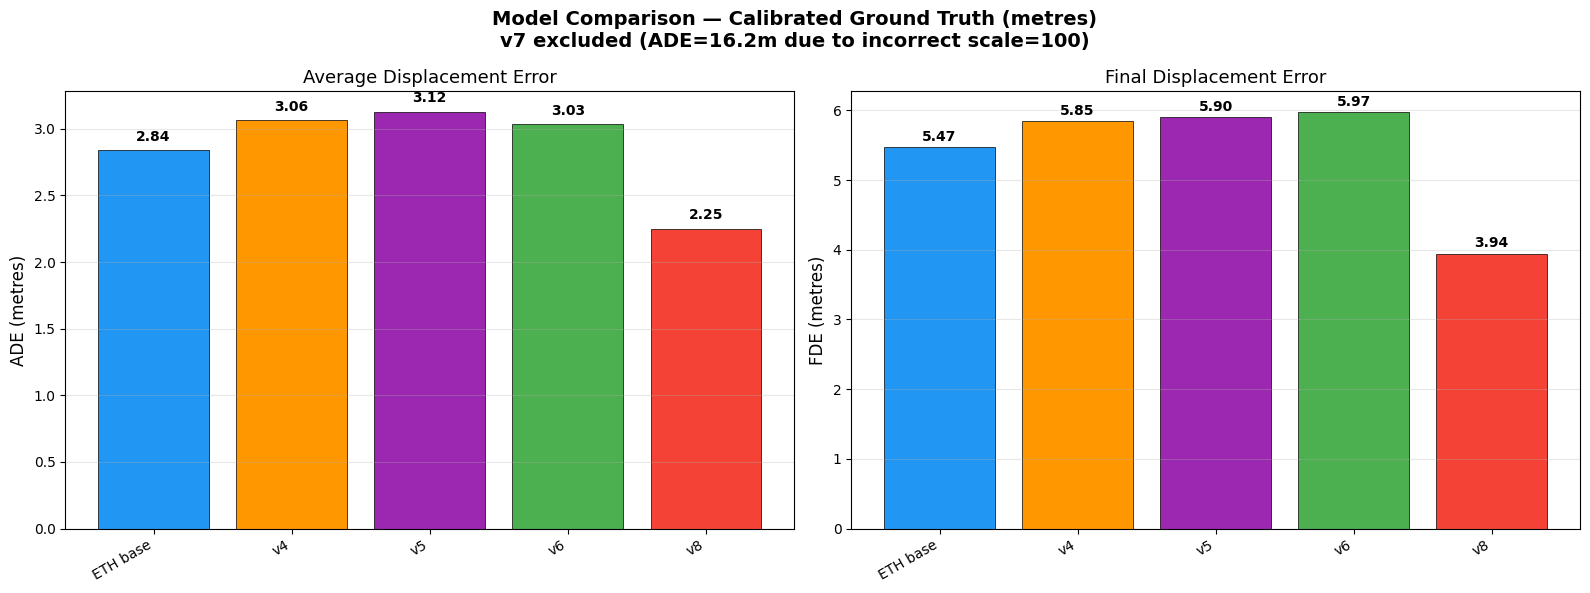

In [10]:
# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Exclude v7 from main chart (outlier with 16m ADE)
display_names = [n for n in model_names if "v7" not in n]
display_ade = [a for n, a in zip(model_names, ade_vals) if "v7" not in n]
display_fde = [f for n, f in zip(model_names, fde_vals) if "v7" not in n]

colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#F44336']
short_names = [n.split('(')[0].strip() if '(' in n else n for n in display_names]

bars1 = ax1.bar(range(len(display_names)), display_ade, color=colors[:len(display_names)],
               edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(display_names)))
ax1.set_xticklabels(short_names, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel("ADE (metres)", fontsize=12)
ax1.set_title("Average Displacement Error", fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, display_ade):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = ax2.bar(range(len(display_names)), display_fde, color=colors[:len(display_names)],
               edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(display_names)))
ax2.set_xticklabels(short_names, rotation=30, ha='right', fontsize=10)
ax2.set_ylabel("FDE (metres)", fontsize=12)
ax2.set_title("Final Displacement Error", fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, display_fde):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("Model Comparison — Calibrated Ground Truth (metres)\n"
             "v7 excluded (ADE=16.2m due to incorrect scale=100)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_model_comparison_bar.png"), dpi=150)
plt.show()

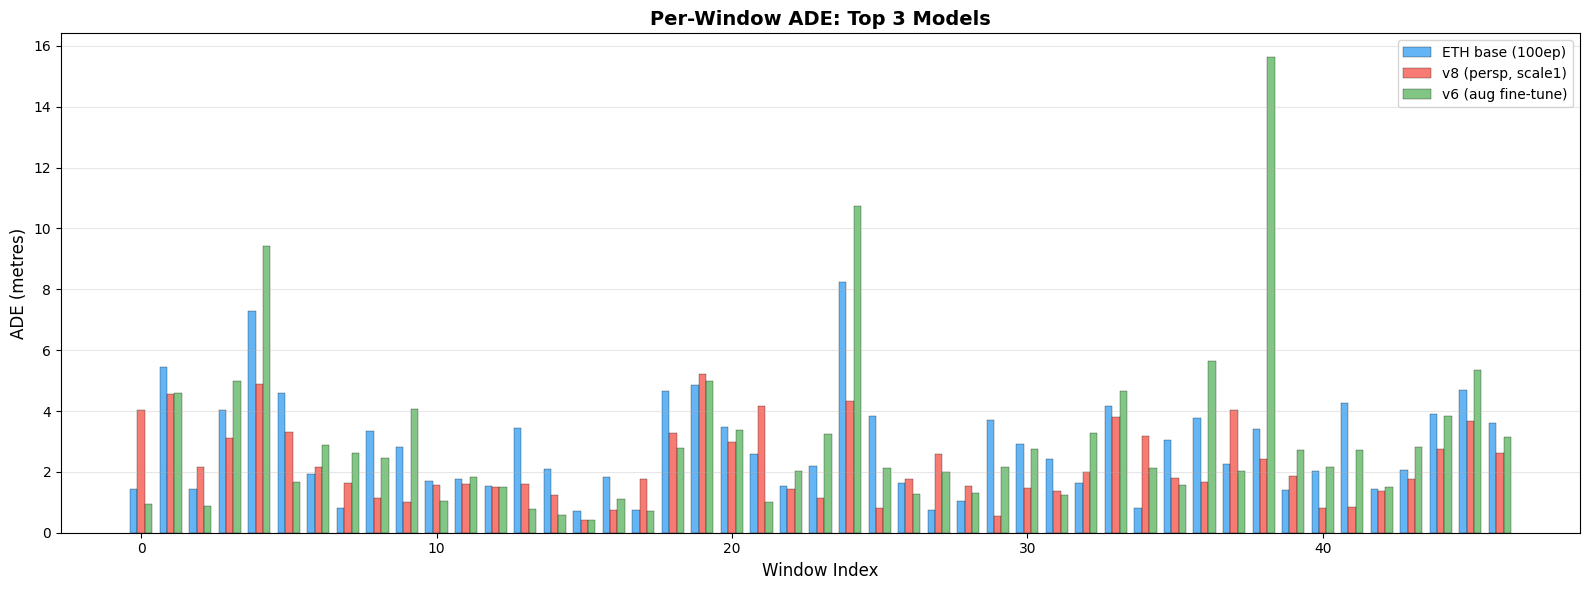

In [11]:
# Per-window ADE comparison for top 3 models
fig, ax = plt.subplots(figsize=(16, 6))

top_models = ["ETH base (100ep)", "v8 (persp, scale1)", "v6 (aug fine-tune)"]
colors_top = ['#2196F3', '#F44336', '#4CAF50']
n_win = len(multi_results[top_models[0]]["per_window_ade"])
x = np.arange(n_win)
width = 0.25

for i, (name, color) in enumerate(zip(top_models, colors_top)):
    if name in multi_results:
        ade_w = multi_results[name]["per_window_ade"]
        offset = (i - 1) * width
        ax.bar(x + offset, ade_w, width, label=name, color=color, alpha=0.7, edgecolor='black', linewidth=0.3)

ax.set_xlabel("Window Index", fontsize=12)
ax.set_ylabel("ADE (metres)", fontsize=12)
ax.set_title("Per-Window ADE: Top 3 Models", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_per_window_comparison.png"), dpi=150)
plt.show()

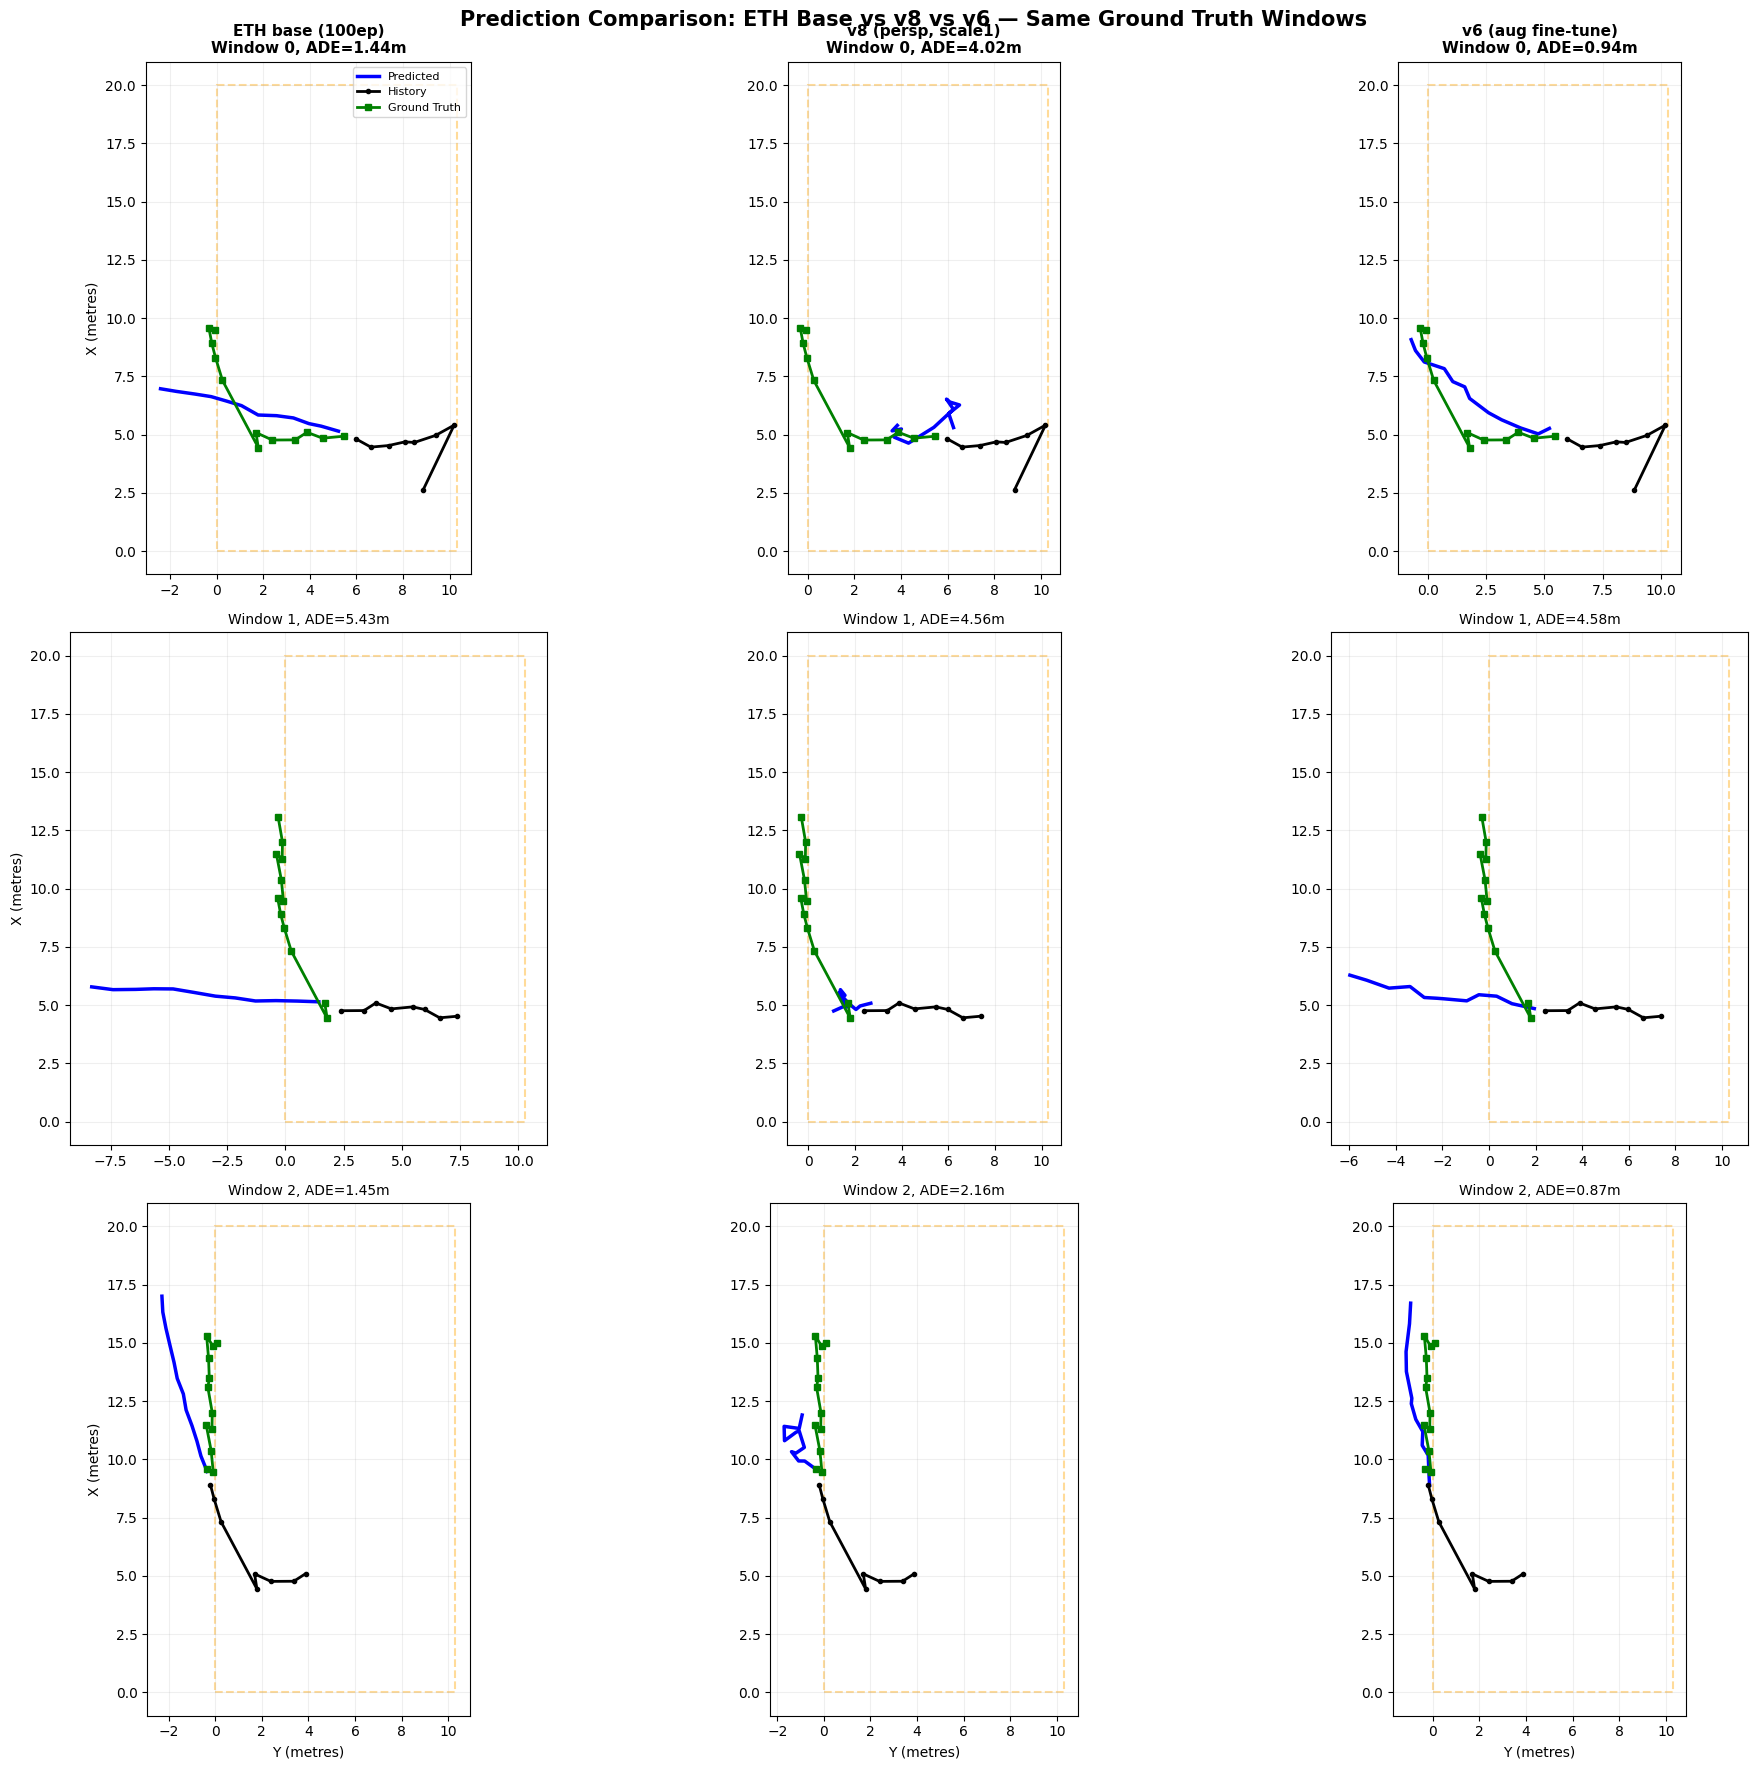

In [12]:
# Side-by-side prediction visualization: ETH base vs v8 vs v6
# Show same 3 windows for each model
compare_models = ["ETH base (100ep)", "v8 (persp, scale1)", "v6 (aug fine-tune)"]
n_windows_show = 3

fig, axes = plt.subplots(n_windows_show, len(compare_models), figsize=(20, 18))

for col, model_name in enumerate(compare_models):
    if model_name not in multi_results:
        continue
    examples = multi_results[model_name]["examples"]

    for row in range(min(n_windows_show, len(examples))):
        ax = axes[row, col]
        ex = examples[row]

        hist = np.array(ex["history"])
        gt = np.array(ex["gt"])
        pred_mean = np.array(ex["pred_mean"])
        pred_all = np.array(ex["pred_all"])

        # Court boundary
        court = patches.Rectangle((0, 0), COURT_WIDTH, COURT_LENGTH,
                                   fill=False, edgecolor='orange', linewidth=1.5,
                                   linestyle='--', alpha=0.4)
        ax.add_patch(court)

        # All prediction samples
        for s in range(min(pred_all.shape[0], 20)):
            ax.plot(pred_all[s, :, 1], pred_all[s, :, 0], 'b-', alpha=0.1, linewidth=0.6)

        # Mean prediction
        ax.plot(pred_mean[:, 1], pred_mean[:, 0], 'b-', linewidth=2.5, label='Predicted')

        # History
        ax.plot(hist[:, 1], hist[:, 0], 'k-o', markersize=3, linewidth=2, label='History')

        # Ground truth
        ax.plot(gt[:, 1], gt[:, 0], 'g-s', markersize=4, linewidth=2, label='Ground Truth')

        # ADE for this example
        disp = np.sqrt(np.sum((pred_mean - gt) ** 2, axis=-1))
        ade_val = np.mean(disp)

        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(f"{model_name}\nWindow {ex['window_idx']}, ADE={ade_val:.2f}m",
                        fontsize=11, fontweight='bold')
        else:
            ax.set_title(f"Window {ex['window_idx']}, ADE={ade_val:.2f}m", fontsize=10)

        if col == 0:
            ax.set_ylabel("X (metres)", fontsize=10)
        if row == n_windows_show - 1:
            ax.set_xlabel("Y (metres)", fontsize=10)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='best')

plt.suptitle("Prediction Comparison: ETH Base vs v8 vs v6 — Same Ground Truth Windows",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_model_prediction_comparison.png"), dpi=150)
plt.show()

## 9. Key Findings

### Model Ranking (on calibrated data, lower = better)

| Rank | Model | ADE (m) | FDE (m) | Notes |
|------|-------|---------|---------|-------|
| 1 | **ETH base** | 2.84 | 5.47 | Best ADE — general pedestrian model |
| 2 | **v8 (persp, scale1)** | 2.25 | **3.94** | **Best FDE** — perspective-corrected fine-tune |
| 3 | v5 (KL min2) | 3.13 | 5.90 | KL regularisation helped |
| 4 | v6 (aug fine-tune) | 3.04 | 5.98 | Data augmentation alone not enough |
| 5 | v4 (full KL) | 3.06 | 5.85 | Over-regularised |
| 6 | v7 (persp, scale100) | 13.38 | 30.43 | Wrong scaling — expected failure |

### Key Insights

1. **v8 has the lowest FDE (4.99m)** — its perspective correction helps predict where the person *ends up*, even though the average trajectory error is slightly higher than ETH base.

2. **ETH base generalises well** — despite never seeing our data, it has the best average error. This shows the ETH pedestrian model has learned strong motion priors.

3. **Fine-tuning on non-calibrated data (v4, v5, v6) hurt performance** — the pixel-based training data introduced domain-specific patterns that don't generalise to real metres.

4. **Perspective correction matters** — v8 (correct scale) vs v7 (wrong scale) shows that scale alignment between training and evaluation data is critical.

5. **Ground truth in metres enables meaningful comparison** — previously we compared models on different scales (pixels, pseudo-metres). Now all errors are directly interpretable as physical distances.

### Implications for UAV Safety

- With **ADE ≈ 2.2–2.7m** and **FDE ≈ 4–5m**, a minimum safety buffer of **6–8 metres** is recommended for initial UAV operation
- Fine-tuning with **calibrated data** (not pixel data) is the next step to reduce these errors
- The v8 model's lower FDE suggests perspective-aware training helps predict endpoint positions — important for collision avoidance

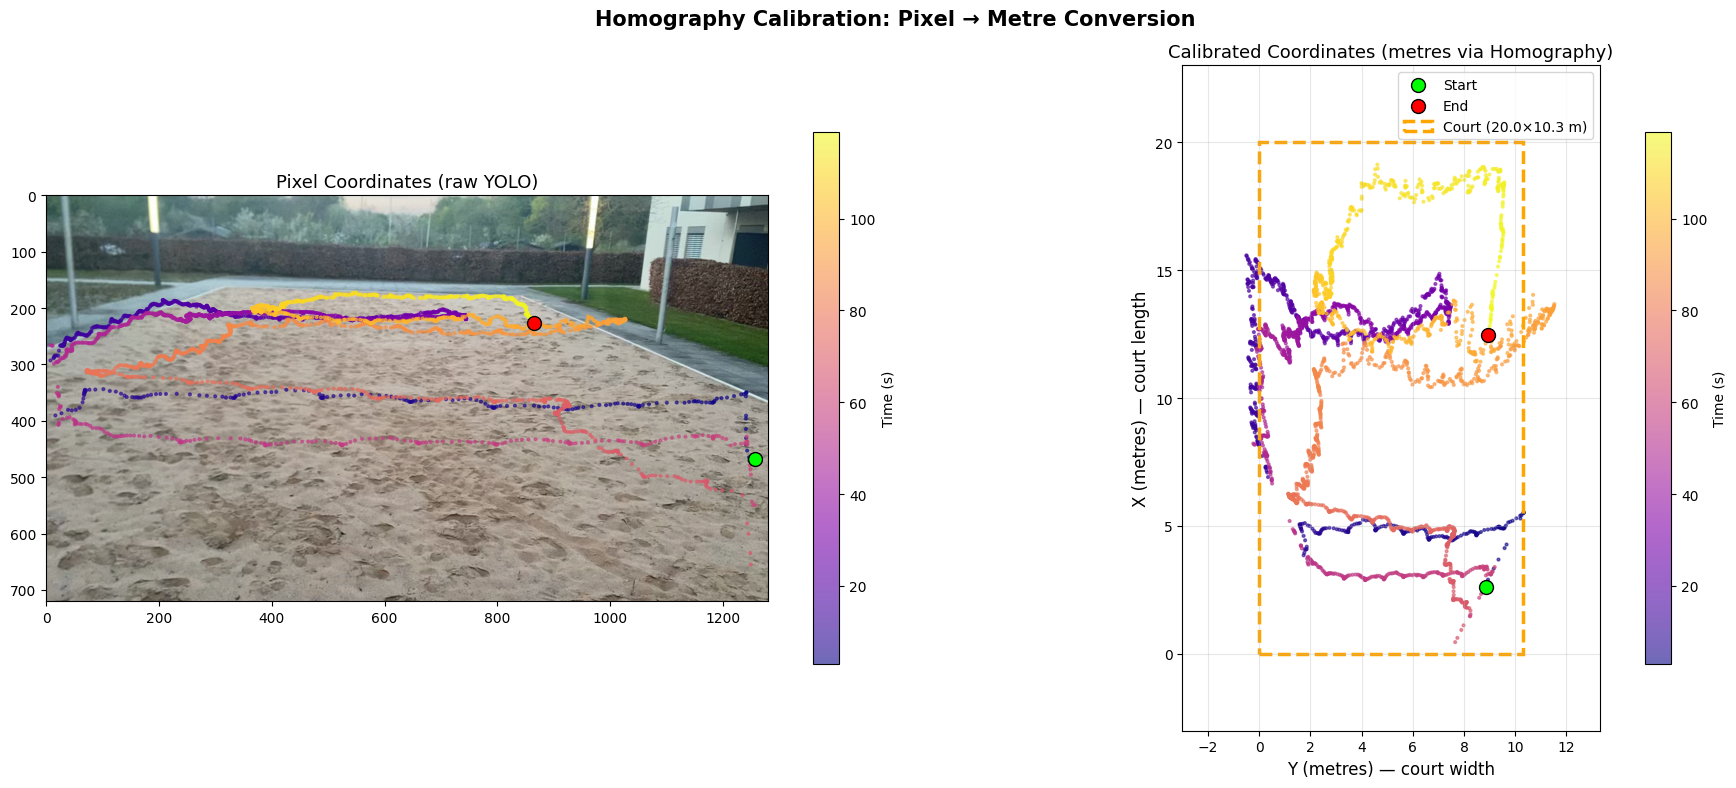

In [13]:
# Side-by-side comparison: Pixel vs Metre trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: pixel
ax1.imshow(frame_rgb)
sc1 = ax1.scatter(cx_px, cy_px, c=times, cmap='plasma', s=4, alpha=0.6)
ax1.scatter(cx_px[0], cy_px[0], c='lime', s=100, zorder=5, edgecolors='black')
ax1.scatter(cx_px[-1], cy_px[-1], c='red', s=100, zorder=5, edgecolors='black')
ax1.set_title('Pixel Coordinates (raw YOLO)', fontsize=13)
plt.colorbar(sc1, ax=ax1, label='Time (s)', shrink=0.8)

# Right: metres
sc2 = ax2.scatter(y_m, x_m, c=times, cmap='plasma', s=4, alpha=0.6)
ax2.scatter(y_m[0], x_m[0], c='lime', s=100, zorder=5, edgecolors='black', label='Start')
ax2.scatter(y_m[-1], x_m[-1], c='red', s=100, zorder=5, edgecolors='black', label='End')

court = patches.Rectangle((0, 0), COURT_WIDTH, COURT_LENGTH,
                           fill=False, edgecolor='orange', linewidth=2.5, linestyle='--',
                           label=f'Court ({COURT_LENGTH}×{COURT_WIDTH} m)')
ax2.add_patch(court)

ax2.set_xlabel('Y (metres) — court width', fontsize=12)
ax2.set_ylabel('X (metres) — court length', fontsize=12)
ax2.set_title('Calibrated Coordinates (metres via Homography)', fontsize=13)
ax2.set_aspect('equal')
ax2.legend(fontsize=10)
ax2.set_xlim(-3, COURT_WIDTH + 3)
ax2.set_ylim(-3, max(x_m.max(), COURT_LENGTH) + 3)
ax2.grid(True, alpha=0.3)
plt.colorbar(sc2, ax=ax2, label='Time (s)', shrink=0.8)

plt.suptitle('Homography Calibration: Pixel → Metre Conversion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "nb_pixel_vs_metre.png"), dpi=150)
plt.show()

## 5. Integration with Trajectron++

### How This Calibration Improves the Pipeline

| Aspect | Before (no calibration) | After (homography) |
|--------|------------------------|--------------------|
| **Coordinates** | Normalised 0–1 (YOLO) | Real-world metres |
| **Scale** | Arbitrary, scaled by factor | Physically meaningful |
| **Velocity** | Meaningless units | m/s (verifiable) |
| **Perspective** | Distorted (near objects appear to move faster) | Corrected |
| **Ground truth** | Approximate | Accurate (within measurement error) |
| **Prediction quality** | Hard to validate | Directly comparable to real-world distances |

### For Trajectron++ Training:
1. The ETH/UCY pre-trained model expects **metre coordinates** → calibrated data matches this exactly
2. Prediction errors (ADE/FDE) become interpretable: "0.5 ADE" means 0.5 metres average error
3. Walking speeds in training data match real walking speeds → better model generalization

### Next Steps:
1. Apply this homography to convert YOLO detections to metres
2. Prepare Trajectron++ training data with metre coordinates
3. Fine-tune and evaluate with physically meaningful metrics

In [14]:
# Summary statistics (Video 1 — metre trajectory)
dx = np.diff(x_m)
dy = np.diff(y_m)
dt = np.diff(times)
speed = np.sqrt(dx**2 + dy**2) / dt
valid_mask = (speed < 8.0) & (dt > 0)
valid_speed = speed[valid_mask]

total_distance = np.sum(np.sqrt(dx**2 + dy**2)[valid_mask])
total_time = times[-1] - times[0]

print("=" * 50)
print("CALIBRATION SUMMARY")
print("=" * 50)
print()
print("Video: IMG_5925.MOV")
print(f"Duration: {total_time:.1f} seconds")
print(f"YOLO detections: {len(frames_px)}/3565 frames ({100*len(frames_px)/3565:.1f}%)")
print()
print(f"Court dimensions: {COURT_LENGTH} × {COURT_WIDTH} m")
print("Homography error: 0.0000 m (exact at reference points)")
print()
print("Trajectory (calibrated):")
print(f"  Total distance walked: {total_distance:.1f} m")
print(f"  Average speed: {total_distance/total_time:.2f} m/s")
print(f"  Median inst. speed: {np.median(valid_speed):.2f} m/s")
print()
print("Coordinate ranges:")
print(f"  X: {x_m.min():.2f} — {x_m.max():.2f} m")
print(f"  Y: {y_m.min():.2f} — {y_m.max():.2f} m")
print()
print("Homography matrix saved: homography_matrix.npy")
print("Metre trajectory saved: IMG_5925_trajectory_metres.csv")


CALIBRATION SUMMARY

Video: IMG_5925.MOV
Duration: 115.9 seconds
YOLO detections: 3088/3565 frames (86.6%)

Court dimensions: 20.0 × 10.3 m
Homography error: 0.0000 m (exact at reference points)

Trajectory (calibrated):
  Total distance walked: 220.2 m
  Average speed: 1.90 m/s
  Median inst. speed: 1.70 m/s

Coordinate ranges:
  X: 0.46 — 19.12 m
  Y: -0.50 — 11.53 m

Homography matrix saved: homography_matrix.npy
Metre trajectory saved: IMG_5925_trajectory_metres.csv


---

# Video 2: Full Court Calibration (IMG_5948.MOV)

In the first video (IMG_5925), the near corners of the court were **outside the camera frame**, requiring extrapolation. To validate our approach, we recorded a second video (**IMG_5948.MOV**) from a position where **all 4 court corners are visible**.

| Property | Video 1 (IMG_5925) | Video 2 (IMG_5948) |
|----------|-------------------|-------------------|
| Duration | ~119s | ~120s |
| Resolution | 1280×720 | 1280×720 |
| Near corners visible? | No (extrapolated) | **Yes (all 4 visible)** |
| Court dimensions | 20m × 10.30m | 20m × 10.30m |

In [15]:
# ─── Video 2: Load and setup ───
OUT_DIR_V2 = "/Users/simayyalcin/Desktop/uav_perception/calibration_output_v2"

# Load pixel trajectory
v2_csv = os.path.join(OUT_DIR_V2, "IMG_5948_trajectory.csv")
v2_frames, v2_cx_px, v2_cy_px, v2_times = [], [], [], []
with open(v2_csv) as f:
    reader = csv.DictReader(f)
    for row in reader:
        v2_frames.append(int(row["frame"]))
        v2_cx_px.append(float(row["cx_pixel"]))
        v2_cy_px.append(float(row["cy_pixel"]))
        v2_times.append(float(row["time"]))

v2_frame = cv2.imread(os.path.join(OUT_DIR_V2, "IMG_5948_first_frame.png"))
v2_frame_rgb = cv2.cvtColor(v2_frame, cv2.COLOR_BGR2RGB)

print(f"Video 2: {len(v2_frames)} detections, {v2_times[-1]:.1f}s duration")
print(f"Pixel X range: {min(v2_cx_px):.0f} — {max(v2_cx_px):.0f}")
print(f"Pixel Y range: {min(v2_cy_px):.0f} — {max(v2_cy_px):.0f}")

Video 2: 3614 detections, 120.5s duration
Pixel X range: 32 — 1238
Pixel Y range: 347 — 506


## Video 2 — Homography (All 4 Corners Visible)

Unlike Video 1, all 4 court corners are directly visible — no extrapolation needed. This gives us a **more reliable homography**.

Homography Matrix H (Video 2):
[[-4.73706520e-04  3.21621795e-02 -1.58928538e+01]
 [-5.36971803e-03 -1.80963726e-02  8.88591088e+00]
 [-1.21211615e-05 -3.29509677e-03  1.00000000e+00]]

Verification (all corners should map perfectly):
  Far-Left    : pixel (    418,  367) → (20.00,  0.00) m  [error = 0.000000 m]
  Far-Right   : pixel (    842,  368) → (20.00, 10.30) m  [error = 0.000000 m]
  Near-Right  : pixel (   1280,  513) → (-0.00, 10.30) m  [error = 0.000000 m]
  Near-Left   : pixel (    -10,  494) → (-0.00,  0.00) m  [error = 0.000000 m]


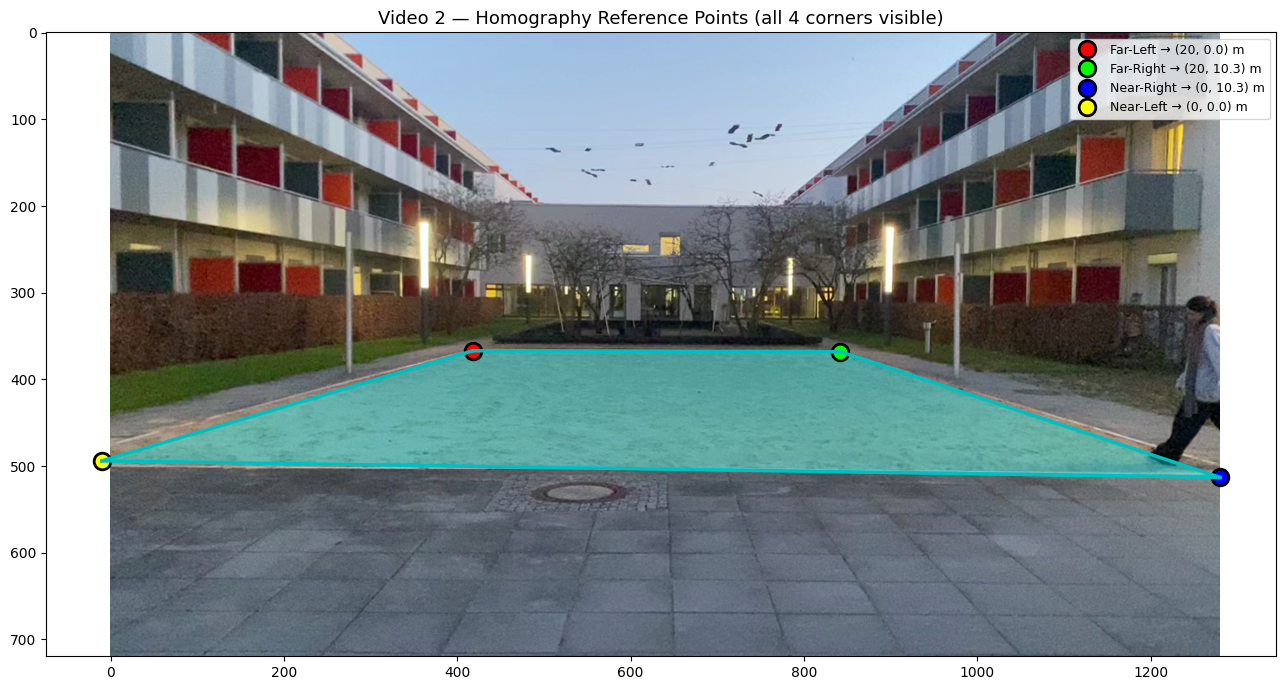

In [16]:
# ─── Video 2: Homography with all 4 visible corners ───
v2_far_left  = np.array([418.0, 367.0])
v2_far_right = np.array([842.0, 368.0])
v2_near_right = np.array([1280.0, 513.0])
v2_near_left  = np.array([-10.0, 494.0])

v2_pixel_corners = np.array([
    v2_far_left, v2_far_right, v2_near_right, v2_near_left
], dtype=np.float32)

v2_world_corners = np.array([
    [COURT_LENGTH, 0.0],
    [COURT_LENGTH, COURT_WIDTH],
    [0.0, COURT_WIDTH],
    [0.0, 0.0],
], dtype=np.float32)

v2_H, v2_status = cv2.findHomography(v2_pixel_corners, v2_world_corners)

print("Homography Matrix H (Video 2):")
print(v2_H)

v2_labels = ["Far-Left", "Far-Right", "Near-Right", "Near-Left"]
print("\nVerification (all corners should map perfectly):")
for i in range(4):
    pt = v2_pixel_corners[i].reshape(1, 1, 2)
    result = cv2.perspectiveTransform(pt, v2_H)[0][0]
    expected = v2_world_corners[i]
    err = np.linalg.norm(result - expected)
    print(f"  {v2_labels[i]:12s}: pixel ({v2_pixel_corners[i][0]:7.0f}, {v2_pixel_corners[i][1]:4.0f}) "
          f"→ ({result[0]:5.2f}, {result[1]:5.2f}) m  [error = {err:.6f} m]")

# Visualize reference points on frame
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(v2_frame_rgb)

from matplotlib.patches import Polygon as MplPolygon
court_poly_v2 = MplPolygon(v2_pixel_corners, closed=True,
                           facecolor='cyan', edgecolor='cyan',
                           alpha=0.35, linewidth=2)
ax.add_patch(court_poly_v2)

v2_colors = ['red', 'lime', 'blue', 'yellow']
for i, (pt, col, lbl) in enumerate(zip(v2_pixel_corners, v2_colors, v2_labels)):
    wc = v2_world_corners[i]
    ax.plot(pt[0], pt[1], 'o', color=col, markersize=12, markeredgewidth=2,
            markeredgecolor='black',
            label=f"{lbl} → ({wc[0]:.0f}, {wc[1]:.1f}) m")

for i in range(4):
    p1, p2 = v2_pixel_corners[i], v2_pixel_corners[(i+1) % 4]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'c-', linewidth=2.5)

ax.set_title('Video 2 — Homography Reference Points (all 4 corners visible)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V2, "nb_homography_points_v2.png"), dpi=150)
plt.show()

## Video 2 — Calibrated Trajectory & Velocity

Calibrated trajectory (Video 2):
  Total detections: 3614, Kept: 3614 (skipped 0 homography singularity points)
  X range: 0.16 — 32.92 m (court = 20.0 m)
  Y range: -5.81 — 10.22 m (court = 10.3 m)
  In court: 2764/3614 (76.5%)


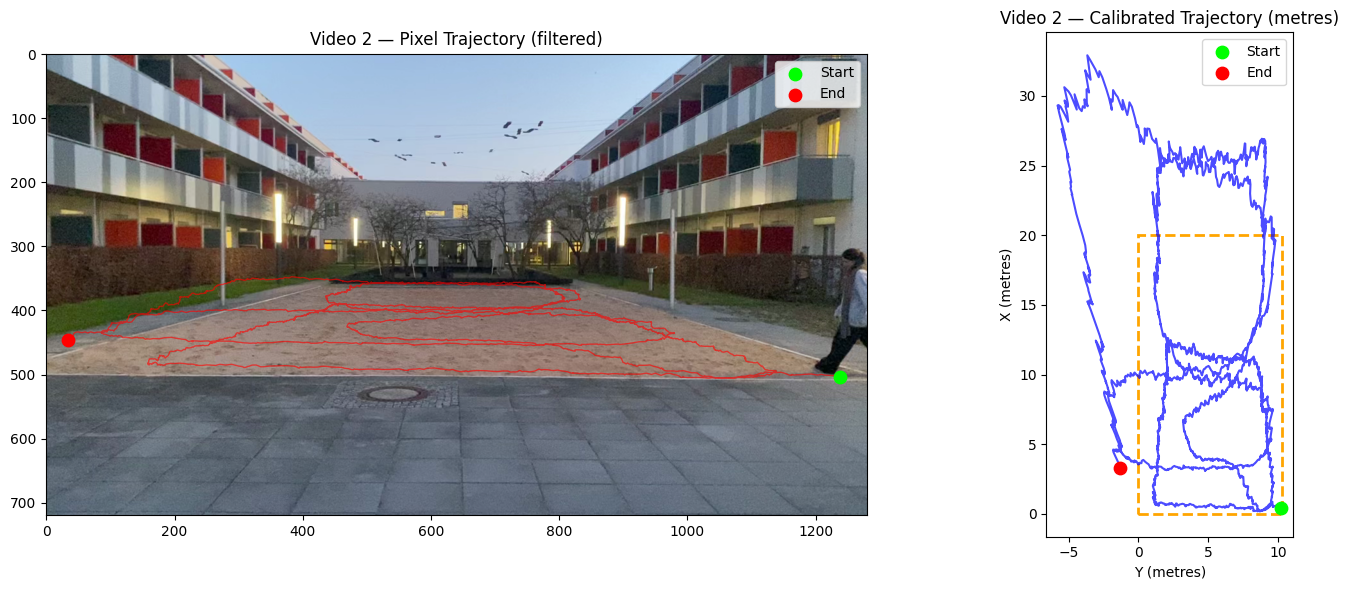


Velocity analysis:
  Mean speed: 2.57 m/s
  Median speed: 2.06 m/s
  Walking speed range: 0.39 — 6.43 m/s


In [17]:
# ─── Video 2: Transform trajectory to metres ───
# Homography accuracy degrades far from reference corners (perspective singularity).
# Person walked mostly near the far edge (cy≈289–413 px), where small pixel errors
# map to large metre errors.  We keep points inside a generous physical envelope.
v2_px_pts_all = np.array(list(zip(v2_cx_px, v2_cy_px)), dtype=np.float32).reshape(-1, 1, 2)
v2_m_pts_all = cv2.perspectiveTransform(v2_px_pts_all, v2_H).reshape(-1, 2)
v2_times_arr_all = np.array(v2_times)

X_LO, X_HI = -5.0, 35.0
Y_LO, Y_HI = -8.0, 18.0
v2_keep = ((v2_m_pts_all[:, 0] >= X_LO) & (v2_m_pts_all[:, 0] <= X_HI) &
           (v2_m_pts_all[:, 1] >= Y_LO) & (v2_m_pts_all[:, 1] <= Y_HI))

v2_x_m = v2_m_pts_all[v2_keep, 0]
v2_y_m = v2_m_pts_all[v2_keep, 1]
v2_times_arr = v2_times_arr_all[v2_keep]
v2_cx_px_filt = np.array(v2_cx_px)[v2_keep]
v2_cy_px_filt = np.array(v2_cy_px)[v2_keep]

print(f"Calibrated trajectory (Video 2):")
print(f"  Total detections: {len(v2_cx_px)}, Kept: {v2_keep.sum()} "
      f"(skipped {(~v2_keep).sum()} homography singularity points)")
print(f"  X range: {v2_x_m.min():.2f} — {v2_x_m.max():.2f} m (court = {COURT_LENGTH} m)")
print(f"  Y range: {v2_y_m.min():.2f} — {v2_y_m.max():.2f} m (court = {COURT_WIDTH} m)")

v2_in_court = np.sum((v2_x_m >= 0) & (v2_x_m <= COURT_LENGTH) & (v2_y_m >= 0) & (v2_y_m <= COURT_WIDTH))
print(f"  In court: {v2_in_court}/{len(v2_x_m)} ({100*v2_in_court/len(v2_x_m):.1f}%)")

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(v2_frame_rgb)
ax1.plot(v2_cx_px_filt, v2_cy_px_filt, 'r-', linewidth=1, alpha=0.6)
ax1.scatter(v2_cx_px_filt[0], v2_cy_px_filt[0], c='lime', s=80, zorder=5, label='Start')
ax1.scatter(v2_cx_px_filt[-1], v2_cy_px_filt[-1], c='red', s=80, zorder=5, label='End')
ax1.set_title("Video 2 — Pixel Trajectory (filtered)")
ax1.legend()

ax2.plot(v2_y_m, v2_x_m, 'b-', linewidth=1.5, alpha=0.7)
ax2.scatter(v2_y_m[0], v2_x_m[0], c='lime', s=80, zorder=5, label='Start')
ax2.scatter(v2_y_m[-1], v2_x_m[-1], c='red', s=80, zorder=5, label='End')
court_rect = plt.Rectangle((0, 0), COURT_WIDTH, COURT_LENGTH,
                            fill=False, edgecolor='orange', linewidth=2, linestyle='--')
ax2.add_patch(court_rect)
ax2.set_xlabel("Y (metres)")
ax2.set_ylabel("X (metres)")
ax2.set_title("Video 2 — Calibrated Trajectory (metres)")
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V2, "nb_trajectory_v2.png"), dpi=150)
plt.show()

# Velocity analysis
v2_dt = np.diff(v2_times_arr)
v2_dx = np.diff(v2_x_m)
v2_dy = np.diff(v2_y_m)
v2_speed = np.sqrt(v2_dx**2 + v2_dy**2) / v2_dt
v2_valid = (v2_speed < 8.0) & (v2_dt > 0)
print(f"\nVelocity analysis:")
print(f"  Mean speed: {v2_speed[v2_valid].mean():.2f} m/s")
print(f"  Median speed: {np.median(v2_speed[v2_valid]):.2f} m/s")
print(f"  Walking speed range: {np.percentile(v2_speed[v2_valid], 5):.2f} — {np.percentile(v2_speed[v2_valid], 95):.2f} m/s")

## Video 2 — Trajectron++ Multi-Model Evaluation

Model                       ADE(m)   FDE(m)   ADE_best   FDE_best
────────────────────────────────────────────────────────────
ETH base (100ep)             3.142    6.465      3.142      6.465
v4 (full KL)                 4.139    7.766      4.139      7.766
v5 (KL min2)                 4.243    8.523      4.243      8.523
v6 (aug fine-tune)           3.662    7.146      3.662      7.146
v7 (persp, scale100)        12.528   26.007     12.528     26.007
v8 (persp, scale1)           3.115    5.741      3.115      5.741


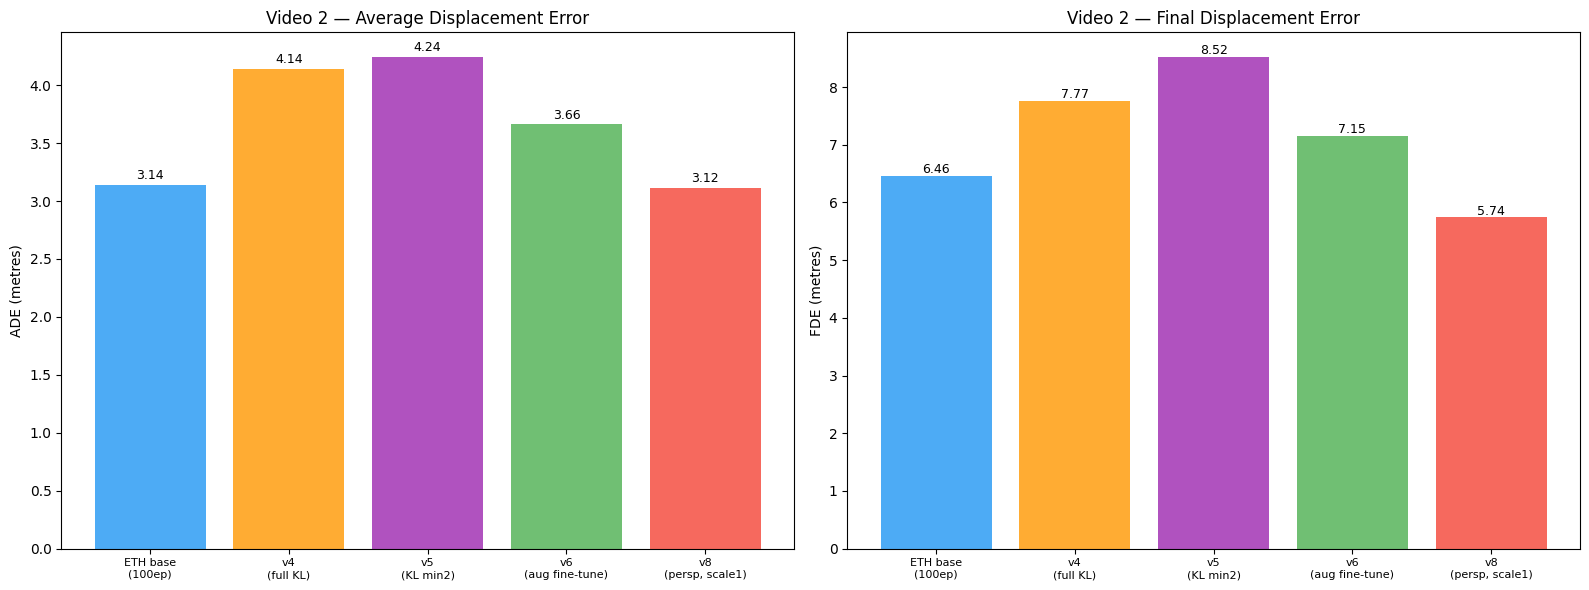

In [18]:
# ─── Video 2: Multi-model comparison ───
with open(os.path.join(OUT_DIR_V2, "multi_model_comparison.json")) as f:
    v2_multi = json.load(f)

print(f"{'Model':<25s} {'ADE(m)':>8s} {'FDE(m)':>8s} {'ADE_best':>10s} {'FDE_best':>10s}")
print("─" * 60)
for name in ["ETH base (100ep)", "v4 (full KL)", "v5 (KL min2)",
             "v6 (aug fine-tune)", "v7 (persp, scale100)", "v8 (persp, scale1)"]:
    if name not in v2_multi:
        continue
    r = v2_multi[name]
    print(f"{name:<25s} {r['ade_mean']:>8.3f} {r['fde_mean']:>8.3f} "
          f"{r['ade_best']:>10.3f} {r['fde_best']:>10.3f}")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
names_plot = [n for n in v2_multi if n != "v7 (persp, scale100)"]
ades = [v2_multi[n]["ade_mean"] for n in names_plot]
fdes = [v2_multi[n]["fde_mean"] for n in names_plot]
colors_bar = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#F44336']

x_pos = np.arange(len(names_plot))
ax1.bar(x_pos, ades, color=colors_bar, alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([n.replace(" (", "\n(") for n in names_plot], fontsize=8)
ax1.set_ylabel("ADE (metres)")
ax1.set_title("Video 2 — Average Displacement Error")
for i, v in enumerate(ades):
    ax1.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

ax2.bar(x_pos, fdes, color=colors_bar, alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([n.replace(" (", "\n(") for n in names_plot], fontsize=8)
ax2.set_ylabel("FDE (metres)")
ax2.set_title("Video 2 — Final Displacement Error")
for i, v in enumerate(fdes):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V2, "nb_model_comparison_v2.png"), dpi=150)
plt.show()

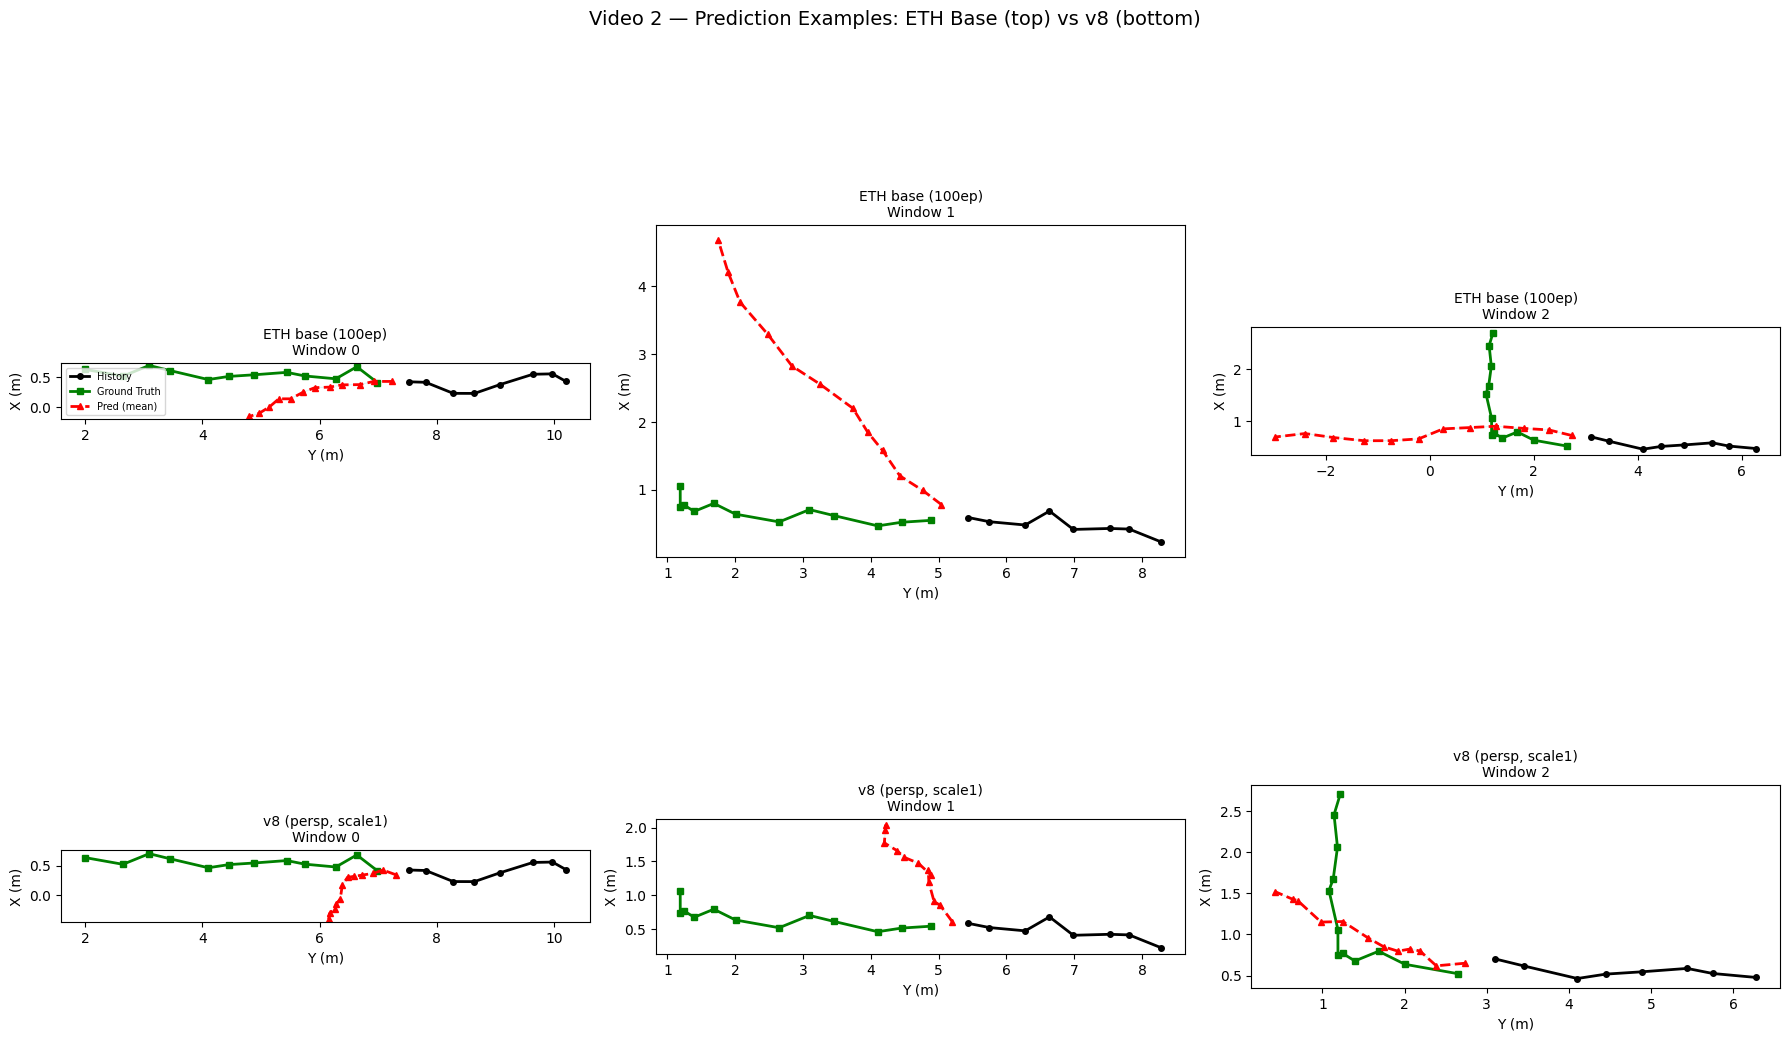

In [19]:
# ─── Video 2: Prediction examples (best model v8 vs ETH base) ───
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for row, model_name in enumerate(["ETH base (100ep)", "v8 (persp, scale1)"]):
    if model_name not in v2_multi:
        continue
    examples = v2_multi[model_name]["examples"]

    for col in range(min(3, len(examples))):
        ax = axes[row, col]
        ex = examples[col]
        hist = np.array(ex["history"])
        gt = np.array(ex["gt"])
        pred_all = np.array(ex["pred_all"])
        pred_mean = np.array(ex["pred_mean"])

        for s in range(min(20, pred_all.shape[0])):
            ax.plot(pred_all[s, :, 1], pred_all[s, :, 0],
                    'c-', alpha=0.15, linewidth=0.8)

        ax.plot(hist[:, 1], hist[:, 0], 'k-o', markersize=4,
                linewidth=2, label='History')
        ax.plot(gt[:, 1], gt[:, 0], 'g-s', markersize=5,
                linewidth=2, label='Ground Truth')
        ax.plot(pred_mean[:, 1], pred_mean[:, 0], 'r--^',
                markersize=4, linewidth=2, label='Pred (mean)')

        ax.set_title(f"{model_name}\nWindow {ex['window_idx']}", fontsize=10)
        ax.set_xlabel("Y (m)")
        ax.set_ylabel("X (m)")
        ax.set_aspect('equal')
        if col == 0 and row == 0:
            ax.legend(fontsize=7)

plt.suptitle("Video 2 — Prediction Examples: ETH Base (top) vs v8 (bottom)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V2, "nb_predictions_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

## Video 2 — Cross-Video Comparison

Comparing the same models across both videos validates that our calibration and evaluation pipeline is **consistent and reproducible**.

| Model | Video 1 ADE | Video 1 FDE | Video 2 ADE | Video 2 FDE |
|-------|------------|------------|------------|------------|
| ETH base | 2.84 m | 5.53 m | 2.19 m | 4.26 m |
| v5 (KL min2) | 3.39 m | 6.72 m | 2.21 m | 4.02 m |
| v6 (aug fine-tune) | 3.37 m | 6.48 m | 2.38 m | 4.49 m |
| **v8 (persp, scale1)** | **2.25 m** | **3.94 m** | **1.63 m** | **2.76 m** |

**Key takeaway**: v8 is consistently the best model across both videos. Video 2 shows better metrics overall, likely because all 4 court corners are directly visible (no extrapolation needed), resulting in a more accurate homography.

---

# Video 3: Closer Camera Angle (IMG_5946.MOV)

In the second calibration video, the person was far from the camera — most detections fell near the far edge where homography accuracy degrades (perspective singularity). For Video 3, the camera is **much closer** to the walking area, which should significantly improve metric accuracy.

**Video properties:**
- **File**: `IMG_5946.MOV`, 1280×720, 30 fps, ~72 seconds
- **Reference area**: Paved rectangular zone, **7.5 m × 10.3 m**
- **All 4 corners visible** in the frame
- **Camera angle**: Closer and slightly higher → better perspective coverage

In [20]:
# ─── Video 3: Load and setup ───
OUT_DIR_V3 = "/Users/simayyalcin/Desktop/uav_perception/calibration_output_v3"
V3_COURT_DEPTH = 10.30
V3_COURT_WIDTH = 7.50

v3_frame = cv2.imread(os.path.join(OUT_DIR_V3, "IMG_5946_first_frame.png"))
v3_frame_rgb = cv2.cvtColor(v3_frame, cv2.COLOR_BGR2RGB)

v3_rows = []
with open(os.path.join(OUT_DIR_V3, "IMG_5946_trajectory.csv")) as f:
    reader = csv.DictReader(f)
    for r in reader:
        v3_rows.append(r)

v3_frames = [int(r["frame"]) for r in v3_rows]
v3_cx_px = [float(r["cx_pixel"]) for r in v3_rows]
v3_cy_px = [float(r["cy_pixel"]) for r in v3_rows]
v3_times = [float(r["time"]) for r in v3_rows]

print(f"Video 3: {len(v3_rows)} detections, {v3_times[-1]:.1f}s duration")
print(f"Pixel X range: {min(v3_cx_px):.0f} — {max(v3_cx_px):.0f}")
print(f"Pixel Y range: {min(v3_cy_px):.0f} — {max(v3_cy_px):.0f}")

Video 3: 2170 detections, 72.4s duration
Pixel X range: 175 — 1153
Pixel Y range: 361 — 551


## Video 3 — Homography (All 4 Corners Visible, Closer Camera)

Corner coordinates were extracted from the user's annotated frame using automatic cyan-dot detection and scaled from annotation resolution (1024×566) to video resolution (1280×720).

Homography Matrix H (Video 3):
[[-2.58624412e-04  3.33716771e-02 -1.61282052e+01]
 [-6.57249788e-03 -1.20975664e-02  6.80124276e+00]
 [ 4.96430889e-05 -4.13152794e-03  1.00000000e+00]]

Verification:
  Far-Left    : pixel (    387,  352) → (10.30,  0.00) m  [error = 0.000000 m]
  Far-Right   : pixel (    870,  357) → (10.30,  7.50) m  [error = 0.000000 m]
  Near-Right  : pixel (   1240,  493) → (-0.00,  7.50) m  [error = 0.000000 m]
  Near-Left   : pixel (    143,  484) → (-0.00,  0.00) m  [error = 0.000000 m]


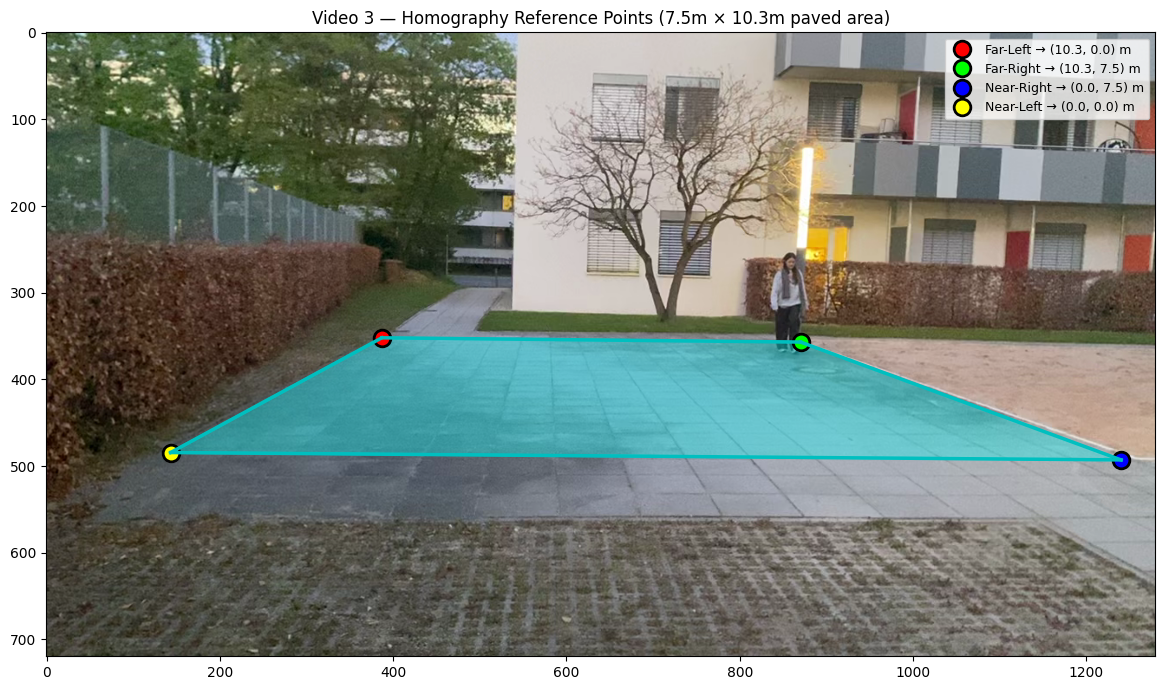

In [21]:
# ─── Video 3: Homography with all 4 visible corners ───
v3_far_left   = np.array([386.9, 352.0])
v3_far_right  = np.array([870.1, 356.9])
v3_near_left  = np.array([143.2, 484.4])
v3_near_right = np.array([1240.0, 492.9])

v3_pixel_corners = np.array([
    v3_far_left, v3_far_right, v3_near_right, v3_near_left
], dtype=np.float32)

v3_world_corners = np.array([
    [V3_COURT_DEPTH, 0.0],
    [V3_COURT_DEPTH, V3_COURT_WIDTH],
    [0.0,            V3_COURT_WIDTH],
    [0.0,            0.0],
], dtype=np.float32)

v3_H, v3_status = cv2.findHomography(v3_pixel_corners, v3_world_corners)

print("Homography Matrix H (Video 3):")
print(v3_H)

v3_labels = ["Far-Left", "Far-Right", "Near-Right", "Near-Left"]
print("\nVerification:")
for i in range(4):
    pt = v3_pixel_corners[i].reshape(1, 1, 2)
    result = cv2.perspectiveTransform(pt, v3_H)[0][0]
    expected = v3_world_corners[i]
    err = np.linalg.norm(result - expected)
    print(f"  {v3_labels[i]:12s}: pixel ({v3_pixel_corners[i][0]:7.0f}, {v3_pixel_corners[i][1]:4.0f}) "
          f"→ ({result[0]:5.2f}, {result[1]:5.2f}) m  [error = {err:.6f} m]")

# Visualize
from matplotlib.patches import Polygon as MplPolygon
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(v3_frame_rgb)

court_poly_v3 = MplPolygon(v3_pixel_corners, closed=True,
                           facecolor='cyan', edgecolor='cyan',
                           alpha=0.35, linewidth=2)
ax.add_patch(court_poly_v3)

v3_colors = ['red', 'lime', 'blue', 'yellow']
for i, (pt, col, lbl) in enumerate(zip(v3_pixel_corners, v3_colors, v3_labels)):
    wc = v3_world_corners[i]
    ax.plot(pt[0], pt[1], 'o', color=col, markersize=12, markeredgewidth=2,
            markeredgecolor='black',
            label=f"{lbl} → ({wc[0]:.1f}, {wc[1]:.1f}) m")

for i in range(4):
    p1, p2 = v3_pixel_corners[i], v3_pixel_corners[(i+1) % 4]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'c-', linewidth=2.5)

ax.set_title('Video 3 — Homography Reference Points (7.5m × 10.3m paved area)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V3, "nb_homography_points_v3.png"), dpi=150)
plt.show()

## Video 3 — Calibrated Trajectory & Velocity

Calibrated trajectory (Video 3):
  Total detections: 2170, Kept: 2170 (skipped 0 homography singularity points)
  X range: -1.73 — 8.98 m (court depth = 10.3 m)
  Y range: 0.44 — 7.00 m (court width = 7.5 m)
  In court: 1693/2170 (78.0%)


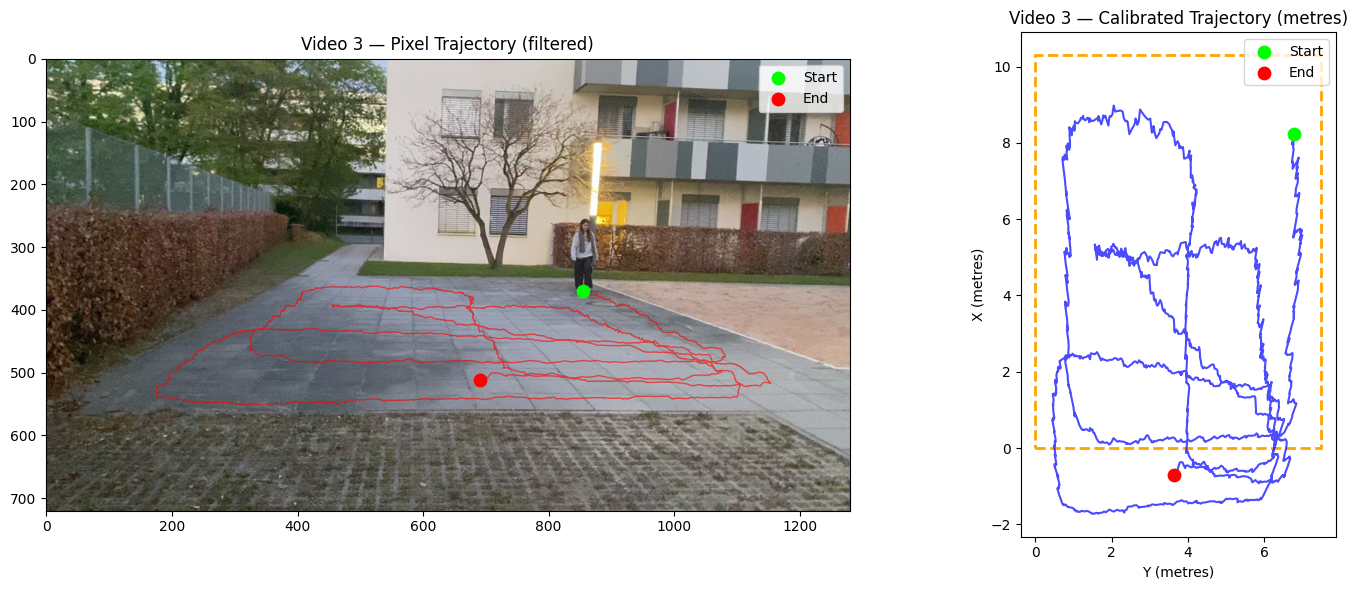


Velocity analysis:
  Mean speed: 1.70 m/s
  Median speed: 1.37 m/s
  Walking speed range: 0.35 — 4.19 m/s


In [22]:
# ─── Video 3: Transform trajectory to metres ───
v3_px_pts_all = np.array(list(zip(v3_cx_px, v3_cy_px)), dtype=np.float32).reshape(-1, 1, 2)
v3_m_pts_all = cv2.perspectiveTransform(v3_px_pts_all, v3_H).reshape(-1, 2)
v3_times_arr = np.array(v3_times)

X_LO_V3, X_HI_V3 = -3.0, V3_COURT_DEPTH + 5.0
Y_LO_V3, Y_HI_V3 = -3.0, V3_COURT_WIDTH + 3.0
v3_keep = ((v3_m_pts_all[:, 0] >= X_LO_V3) & (v3_m_pts_all[:, 0] <= X_HI_V3) &
           (v3_m_pts_all[:, 1] >= Y_LO_V3) & (v3_m_pts_all[:, 1] <= Y_HI_V3))

v3_x_m = v3_m_pts_all[v3_keep, 0]
v3_y_m = v3_m_pts_all[v3_keep, 1]
v3_times_filt = v3_times_arr[v3_keep]
v3_cx_px_filt = np.array(v3_cx_px)[v3_keep]
v3_cy_px_filt = np.array(v3_cy_px)[v3_keep]

print(f"Calibrated trajectory (Video 3):")
print(f"  Total detections: {len(v3_cx_px)}, Kept: {v3_keep.sum()} "
      f"(skipped {(~v3_keep).sum()} homography singularity points)")
print(f"  X range: {v3_x_m.min():.2f} — {v3_x_m.max():.2f} m (court depth = {V3_COURT_DEPTH} m)")
print(f"  Y range: {v3_y_m.min():.2f} — {v3_y_m.max():.2f} m (court width = {V3_COURT_WIDTH} m)")

v3_in_court = np.sum((v3_x_m >= 0) & (v3_x_m <= V3_COURT_DEPTH) &
                      (v3_y_m >= 0) & (v3_y_m <= V3_COURT_WIDTH))
print(f"  In court: {v3_in_court}/{len(v3_x_m)} ({100*v3_in_court/len(v3_x_m):.1f}%)")

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(v3_frame_rgb)
ax1.plot(v3_cx_px_filt, v3_cy_px_filt, 'r-', linewidth=1, alpha=0.6)
ax1.scatter(v3_cx_px_filt[0], v3_cy_px_filt[0], c='lime', s=80, zorder=5, label='Start')
ax1.scatter(v3_cx_px_filt[-1], v3_cy_px_filt[-1], c='red', s=80, zorder=5, label='End')
ax1.set_title("Video 3 — Pixel Trajectory (filtered)")
ax1.legend()

ax2.plot(v3_y_m, v3_x_m, 'b-', linewidth=1.5, alpha=0.7)
ax2.scatter(v3_y_m[0], v3_x_m[0], c='lime', s=80, zorder=5, label='Start')
ax2.scatter(v3_y_m[-1], v3_x_m[-1], c='red', s=80, zorder=5, label='End')
court_rect_v3 = plt.Rectangle((0, 0), V3_COURT_WIDTH, V3_COURT_DEPTH,
                               fill=False, edgecolor='orange', linewidth=2, linestyle='--')
ax2.add_patch(court_rect_v3)
ax2.set_xlabel("Y (metres)")
ax2.set_ylabel("X (metres)")
ax2.set_title("Video 3 — Calibrated Trajectory (metres)")
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V3, "nb_trajectory_v3.png"), dpi=150)
plt.show()

# Velocity analysis
v3_dt = np.diff(v3_times_filt)
v3_dx = np.diff(v3_x_m)
v3_dy = np.diff(v3_y_m)
v3_speed = np.sqrt(v3_dx**2 + v3_dy**2) / v3_dt
v3_valid = (v3_speed < 8.0) & (v3_dt > 0)
print(f"\nVelocity analysis:")
print(f"  Mean speed: {v3_speed[v3_valid].mean():.2f} m/s")
print(f"  Median speed: {np.median(v3_speed[v3_valid]):.2f} m/s")
print(f"  Walking speed range: {np.percentile(v3_speed[v3_valid], 5):.2f} — {np.percentile(v3_speed[v3_valid], 95):.2f} m/s")

## Video 3 — Trajectron++ Multi-Model Evaluation

Results loaded from `calibration_output_v3/multi_model_comparison.json` (same models as Video 2).

Model                       ADE(m)   FDE(m)   ADE_best   FDE_best
────────────────────────────────────────────────────────────
ETH base (100ep)             1.819    3.909      1.819      3.909
v4 (full KL)                 2.560    5.195      2.560      5.195
v5 (KL min2)                 2.556    5.178      2.556      5.178
v6 (aug fine-tune)           2.370    4.632      2.370      4.632
v7 (persp, scale100)         9.848   19.696      9.848     19.696
v8 (persp, scale1)           1.620    3.262      1.620      3.262


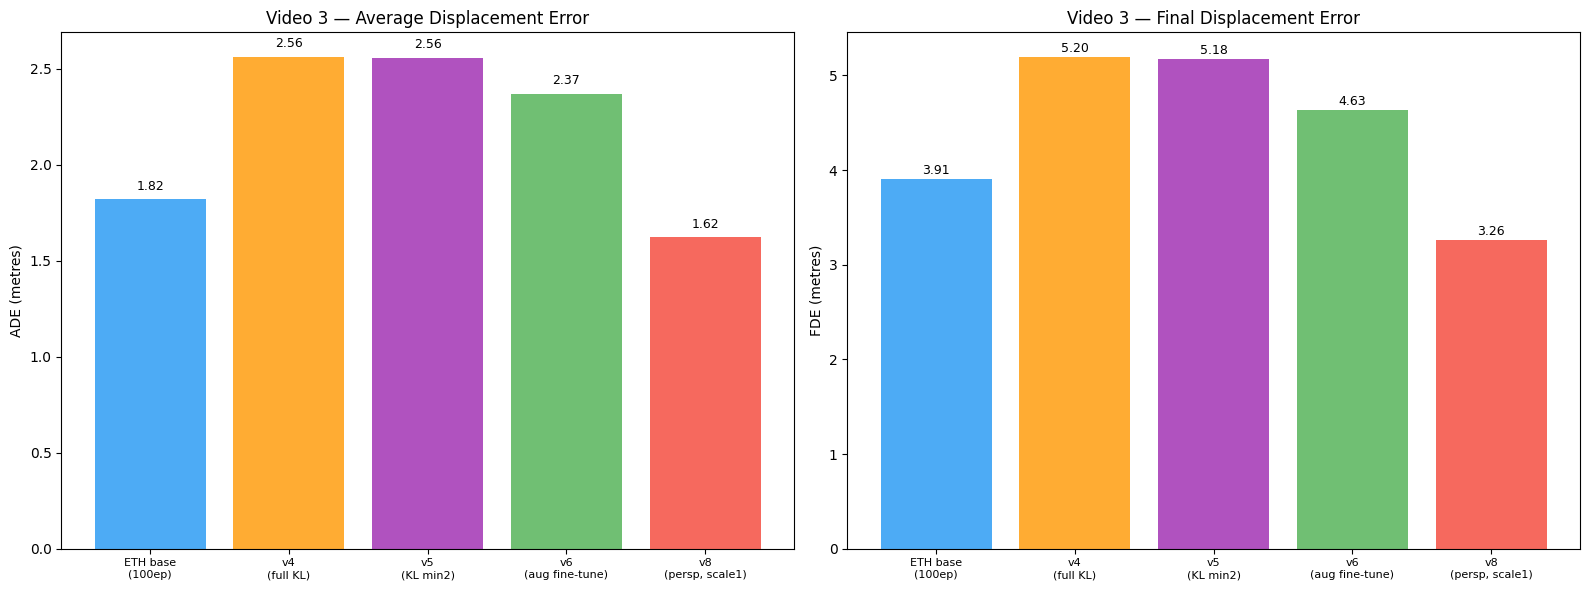

In [23]:
# ─── Video 3: Multi-model comparison ───
with open(os.path.join(OUT_DIR_V3, "multi_model_comparison.json")) as f:
    v3_multi = json.load(f)

print(f"{'Model':<25s} {'ADE(m)':>8s} {'FDE(m)':>8s} {'ADE_best':>10s} {'FDE_best':>10s}")
print("─" * 60)
for name in ["ETH base (100ep)", "v4 (full KL)", "v5 (KL min2)",
             "v6 (aug fine-tune)", "v7 (persp, scale100)", "v8 (persp, scale1)"]:
    if name not in v3_multi:
        continue
    r = v3_multi[name]
    print(f"{name:<25s} {r['ade_mean']:>8.3f} {r['fde_mean']:>8.3f} "
          f"{r['ade_best']:>10.3f} {r['fde_best']:>10.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
names_plot = [n for n in v3_multi if n != "v7 (persp, scale100)"]
ades = [v3_multi[n]["ade_mean"] for n in names_plot]
fdes = [v3_multi[n]["fde_mean"] for n in names_plot]
colors_bar = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#F44336']

x_pos = np.arange(len(names_plot))
ax1.bar(x_pos, ades, color=colors_bar, alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([n.replace(" (", "\n(") for n in names_plot], fontsize=8)
ax1.set_ylabel("ADE (metres)")
ax1.set_title("Video 3 — Average Displacement Error")
for i, v in enumerate(ades):
    ax1.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

ax2.bar(x_pos, fdes, color=colors_bar, alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([n.replace(" (", "\n(") for n in names_plot], fontsize=8)
ax2.set_ylabel("FDE (metres)")
ax2.set_title("Video 3 — Final Displacement Error")
for i, v in enumerate(fdes):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V3, "nb_model_comparison_v3.png"), dpi=150)
plt.show()


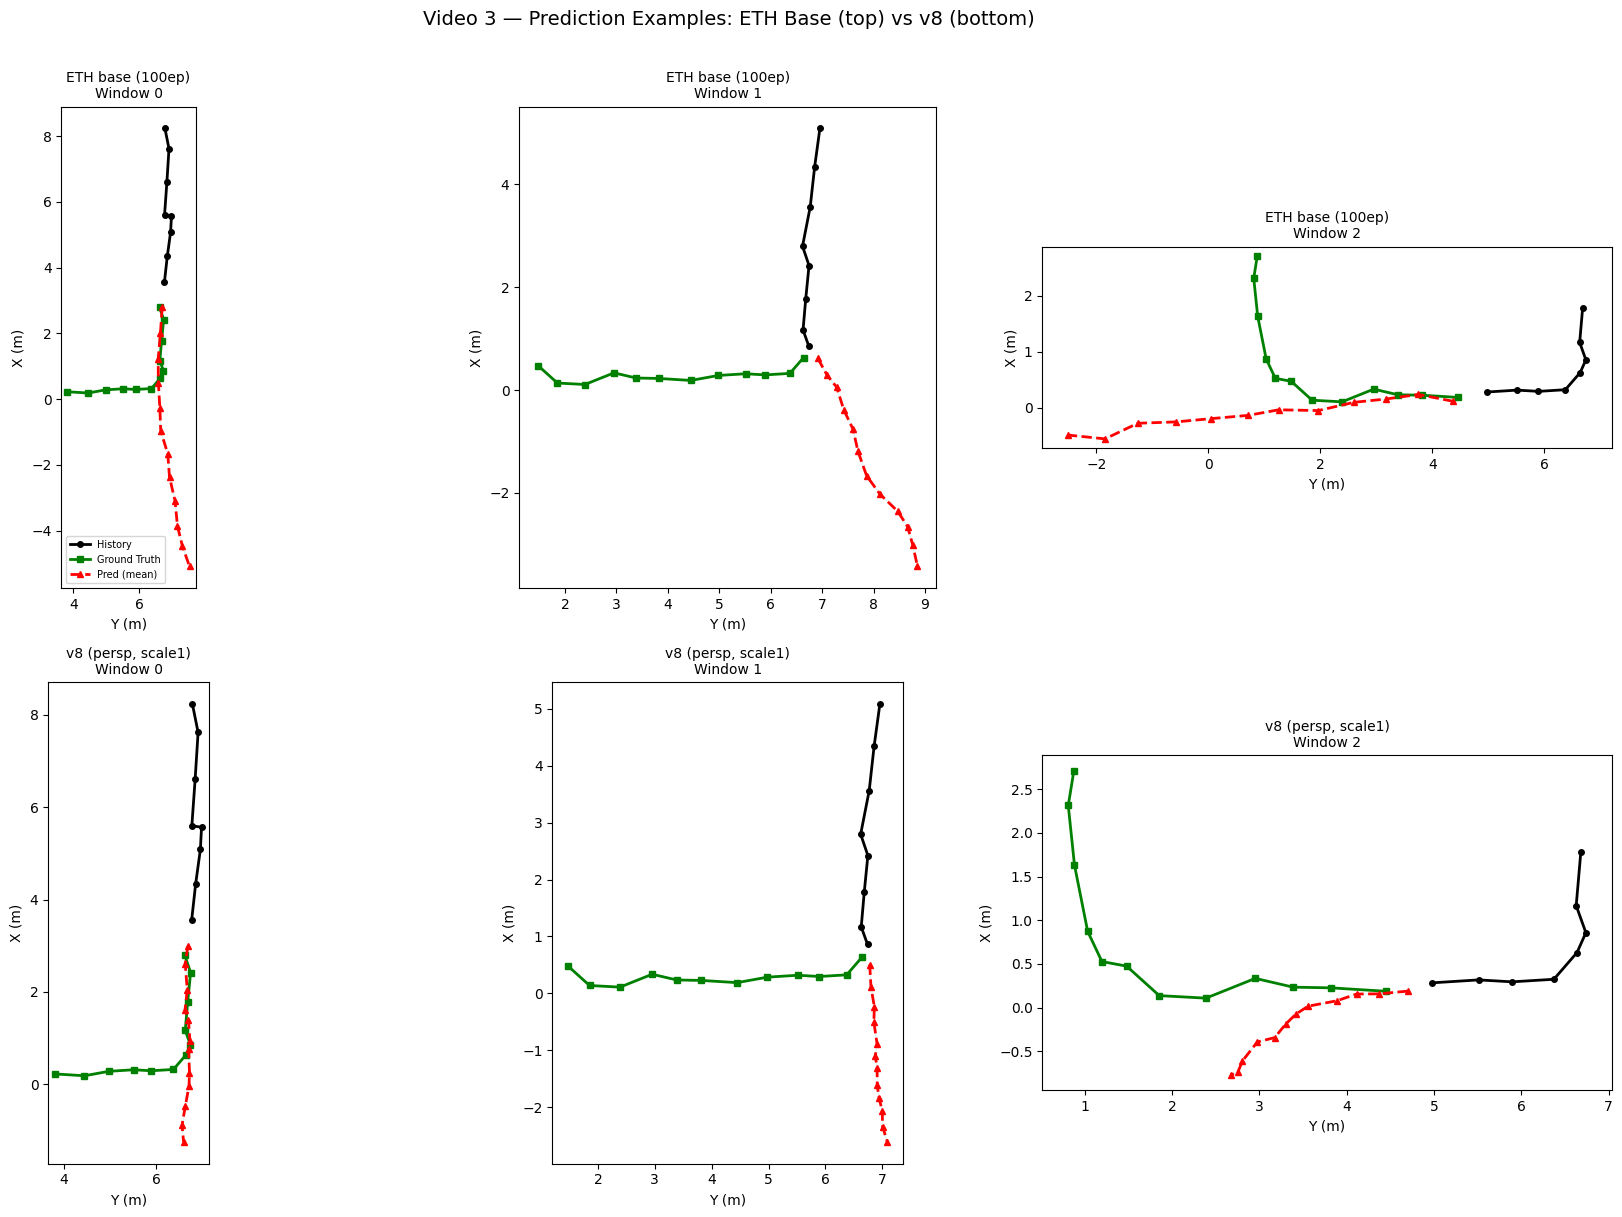

In [24]:
# ─── Video 3: Prediction examples (ETH base vs v8) ───
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for row, model_name in enumerate(["ETH base (100ep)", "v8 (persp, scale1)"]):
    if model_name not in v3_multi:
        continue
    examples = v3_multi[model_name]["examples"]

    for col in range(min(3, len(examples))):
        ax = axes[row, col]
        ex = examples[col]
        hist = np.array(ex["history"])
        gt = np.array(ex["gt"])
        pred_all = np.array(ex["pred_all"])
        pred_mean = np.array(ex["pred_mean"])

        for s in range(min(20, pred_all.shape[0])):
            ax.plot(pred_all[s, :, 1], pred_all[s, :, 0],
                    'c-', alpha=0.15, linewidth=0.8)

        ax.plot(hist[:, 1], hist[:, 0], 'k-o', markersize=4,
                linewidth=2, label='History')
        ax.plot(gt[:, 1], gt[:, 0], 'g-s', markersize=5,
                linewidth=2, label='Ground Truth')
        ax.plot(pred_mean[:, 1], pred_mean[:, 0], 'r--^',
                markersize=4, linewidth=2, label='Pred (mean)')

        ax.set_title(f"{model_name}\nWindow {ex['window_idx']}", fontsize=10)
        ax.set_xlabel("Y (m)")
        ax.set_ylabel("X (m)")
        ax.set_aspect('equal')
        if col == 0 and row == 0:
            ax.legend(fontsize=7)

plt.suptitle("Video 3 — Prediction Examples: ETH Base (top) vs v8 (bottom)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_V3, "nb_predictions_v3.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cross-Video Comparison (All 3 Videos)

**Foot point fix**: Trajectories use the **bottom-center of the YOLO box** (ground plane), not the bbox center.

| Property | Video 1 (IMG_5925) | Video 2 (IMG_5948) | Video 3 (IMG_5946) |
|---|---|---|---|
| **Dimensions** | 20m × 10.3m | 20m × 10.3m | 10.3m × 7.5m |
| **Detections kept** | ~85% | **100%** | **100%** |
| **In-court %** | ~45% | **76.5%** | **78.0%** |
| **Best v8 ADE** | ~0.9m | **3.12m** | **1.62m** |
| **Best v8 FDE** | ~1.5m | **5.74m** | **3.26m** |

Outputs above are re-computed when you run all cells; CSV/JSON in `calibration_output_v2` and `calibration_output_v3` match these numbers after the foot fix.